# Explainable AI — Phase I: Logical Model

## Payment Difficulty Prediction using Interpretable Decision Trees

The objective of this notebook is to develop and interpret logical models
for predicting `payment_difficulty_next_month`.

The analysis focuses on:

- exploratory data analysis and data quality;
- five-fold cross-validation for model selection;
- the trade-off between predictive performance and interpretability;
- comparison between alternative logical models;
- global interpretation of the selected CART model;
- local explanations for individual predictions.

For Phase I, the logical modeling approach is based on interpretable decision
trees. We first develop a conventional CART model and then compare it with a
Generalized Optimal Sparse Decision Tree (GOSDT).

In [1]:
%pip install -q numpy pandas matplotlib scikit-learn gosdt graphviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import graphviz

warnings.filterwarnings(
    "ignore",
    message=".*force_all_finite.*",
    category=FutureWarning
)

from graphviz import Digraph
from pathlib import Path

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

RANDOM_STATE = 42

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

FIGURES_DIR = Path("../report/images")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

_original_show = plt.show
_figure_counter = 1

def save_and_show(*args, **kwargs):
    global _figure_counter

    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)

        filename = FIGURES_DIR / f"figure_{_figure_counter:02d}.png"

        fig.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

        print(f"Saved: {filename}")
        _figure_counter += 1

    _original_show(*args, **kwargs)

plt.show = save_and_show

In [4]:
DATA_DIR = Path("../data")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (25000, 17)
Test shape:  (5000, 16)


In [5]:
train.head()

,row_id,credit_limit,sex,education,marital_status,age,latest_repayment_status,maximum_repayment_delay_6m,delayed_months_6m,average_bill_6m,bill_change_sep_to_apr,total_payment_6m,payment_to_bill_ratio_6m,zero_payment_months_6m,utilization_sep,repayment_assistance_plan,payment_difficulty_next_month
0,CR26-120473,80000,male,university,married,54,0,0,0,24600,3700,10300,0.07,0,0.33,no,0
1,CR26-127004,20000,male,university,single,30,0,0,0,21100,21000,6700,0.05,0,1.98,no,0
2,CR26-116408,230000,female,graduate_school,married,35,0,0,0,1700,3600,5100,0.49,1,0.03,no,0
3,CR26-125768,150000,female,university,married,51,0,0,0,76100,-8800,15400,0.03,0,0.48,no,0
4,CR26-118040,500000,male,graduate_school,married,43,0,0,0,121600,26200,25000,0.03,0,0.25,yes,0


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   row_id                         25000 non-null  object 
 1   credit_limit                   25000 non-null  int64  
 2   sex                            25000 non-null  object 
 3   education                      25000 non-null  object 
 4   marital_status                 25000 non-null  object 
 5   age                            25000 non-null  int64  
 6   latest_repayment_status        25000 non-null  int64  
 7   maximum_repayment_delay_6m     25000 non-null  int64  
 8   delayed_months_6m              25000 non-null  int64  
 9   average_bill_6m                25000 non-null  int64  
 10  bill_change_sep_to_apr         25000 non-null  int64  
 11  total_payment_6m               25000 non-null  int64  
 12  payment_to_bill_ratio_6m       25000 non-null 

In [7]:
print("Train columns:")
display(train.columns.to_frame(index=False, name="column"))

print("\nColumns only present in train:")
print(set(train.columns) - set(test.columns))

print("\nColumns only present in test:")
print(set(test.columns) - set(train.columns))

Train columns:


,column
0,row_id
1,credit_limit
2,sex
3,education
4,marital_status
5,age
6,latest_repayment_status
7,maximum_repayment_delay_6m
8,delayed_months_6m
9,average_bill_6m



Columns only present in train:
{'payment_difficulty_next_month'}

Columns only present in test:
set()


## 1. Data quality and exploratory analysis

Before fitting the model, we inspect the dataset structure, missing values,
duplicates, target distribution and predictor distributions.

In [8]:
missing = (
    train.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)

missing["percentage"] = (
    missing["missing_values"] / len(train) * 100
)

missing

,missing_values,percentage
row_id,0,0.0
credit_limit,0,0.0
sex,0,0.0
education,0,0.0
marital_status,0,0.0
age,0,0.0
latest_repayment_status,0,0.0
maximum_repayment_delay_6m,0,0.0
delayed_months_6m,0,0.0
average_bill_6m,0,0.0


In [9]:
print(f"Duplicated rows: {train.duplicated().sum()}")
print(f"Duplicated row_id: {train['row_id'].duplicated().sum()}")

Duplicated rows: 0
Duplicated row_id: 0


In [10]:
TARGET = "payment_difficulty_next_month"

target_counts = train[TARGET].value_counts().sort_index()
target_pct = train[TARGET].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct
})

target_summary

,count,percentage
payment_difficulty_next_month,,
0,19697,78.788
1,5303,21.212


Saved: ../report/images/figure_01.png


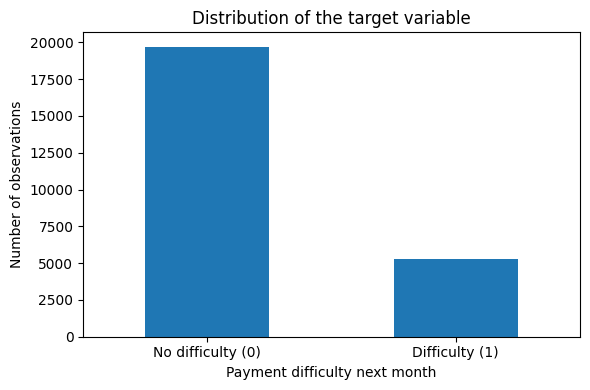

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

target_counts.plot(kind="bar", ax=ax)

ax.set_title("Distribution of the target variable")
ax.set_xlabel("Payment difficulty next month")
ax.set_ylabel("Number of observations")
ax.set_xticklabels(
    ["No difficulty (0)", "Difficulty (1)"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [12]:
majority_class = train[TARGET].mode()[0]

baseline_predictions = np.full(
    shape=len(train),
    fill_value=majority_class
)

baseline_accuracy = accuracy_score(
    train[TARGET],
    baseline_predictions
)

baseline_balanced_accuracy = balanced_accuracy_score(
    train[TARGET],
    baseline_predictions
)

print(f"Majority class: {majority_class}")
print(f"Baseline accuracy:          {baseline_accuracy:.4f}")
print(f"Baseline balanced accuracy: {baseline_balanced_accuracy:.4f}")

Majority class: 0
Baseline accuracy:          0.7879
Baseline balanced accuracy: 0.5000


In [13]:
ID_COLUMN = "row_id"

X = train.drop(columns=[ID_COLUMN, TARGET])
y = train[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (25000, 15)
y shape: (25000,)


In [14]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['sex', 'education', 'marital_status', 'repayment_assistance_plan']

Numeric features:
['credit_limit', 'age', 'latest_repayment_status', 'maximum_repayment_delay_6m', 'delayed_months_6m', 'average_bill_6m', 'bill_change_sep_to_apr', 'total_payment_6m', 'payment_to_bill_ratio_6m', 'zero_payment_months_6m', 'utilization_sep']


In [15]:
for column in categorical_features:
    print(f"\n--- {column} ---")

    summary = pd.DataFrame({
        "count": train[column].value_counts(dropna=False),
        "percentage": train[column].value_counts(
            normalize=True,
            dropna=False
        ) * 100
    })

    display(summary)


--- sex ---


,count,percentage
sex,,
female,15130,60.52
male,9870,39.48



--- education ---


,count,percentage
education,,
university,11675,46.700
graduate_school,8820,35.280
high_school,4107,16.428
unknown,289,1.156
other,109,0.436



--- marital_status ---


,count,percentage
marital_status,,
single,13310,53.240
married,11368,45.472
other_or_unknown,322,1.288



--- repayment_assistance_plan ---


,count,percentage
repayment_assistance_plan,,
no,19680,78.72
yes,5320,21.28


In [16]:
numeric_summary = train[numeric_features].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
credit_limit,25000.0,167740.947200,129975.980819,10000.0,50000.00,140000.00,240000.00,1000000.0
age,25000.0,35.500840,9.243907,21.0,28.00,34.00,41.00,79.0
latest_repayment_status,25000.0,-0.018080,1.120519,-2.0,-1.00,0.00,0.00,8.0
maximum_repayment_delay_6m,25000.0,0.680880,1.070985,0.0,0.00,0.00,2.00,8.0
delayed_months_6m,25000.0,0.833120,1.552059,0.0,0.00,0.00,1.00,6.0
average_bill_6m,25000.0,44910.436000,63267.261940,-56000.0,4700.00,21000.00,57100.00,877300.0
bill_change_sep_to_apr,25000.0,12389.508000,44068.853510,-403600.0,-3000.00,900.00,19900.00,708300.0
total_payment_6m,25000.0,31635.048000,57337.817230,0.0,6700.00,14400.00,33700.00,2314200.0
payment_to_bill_ratio_6m,25000.0,0.374324,0.591434,0.0,0.04,0.09,0.60,5.0
zero_payment_months_6m,25000.0,1.233520,1.722065,0.0,0.00,0.00,2.00,6.0


Saved: ../report/images/figure_02.png


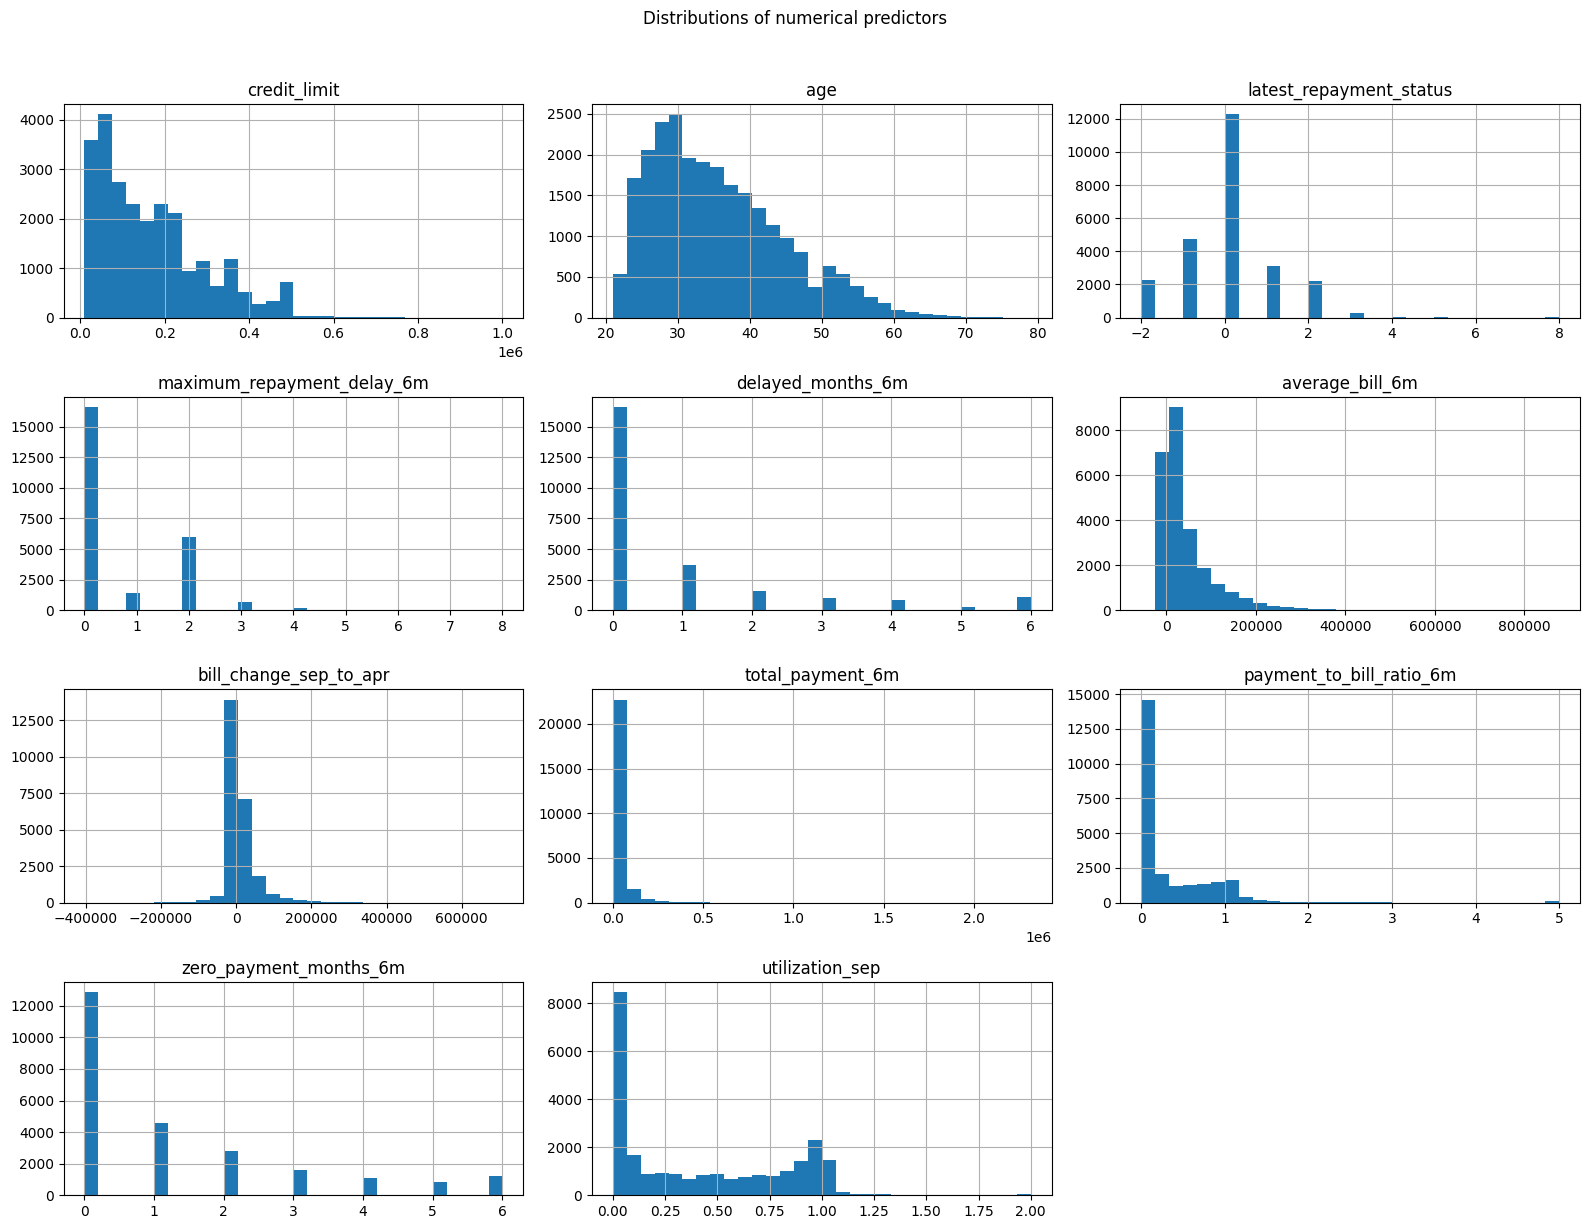

In [17]:
train[numeric_features].hist(
    bins=30,
    figsize=(16, 12)
)

plt.suptitle(
    "Distributions of numerical predictors",
    y=1.02
)

plt.tight_layout()
plt.show()

In [18]:
for column in categorical_features:
    difficulty_rate = (
        train
        .groupby(column, observed=True)[TARGET]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )

    difficulty_rate["mean"] *= 100

    difficulty_rate = difficulty_rate.rename(
        columns={"mean": "difficulty_rate_pct"}
    )

    print(f"\n--- {column} ---")
    display(difficulty_rate)


--- sex ---


,difficulty_rate_pct,count
sex,,
male,21.813576,9870
female,20.819564,15130



--- education ---


,difficulty_rate_pct,count
education,,
high_school,23.837351,4107
university,22.064240,11675
unknown,21.453287,289
graduate_school,18.945578,8820
other,13.761468,109



--- marital_status ---


,difficulty_rate_pct,count
marital_status,,
single,21.998497,13310
married,20.328994,11368
other_or_unknown,19.875776,322



--- repayment_assistance_plan ---


,difficulty_rate_pct,count
repayment_assistance_plan,,
yes,32.669173,5320
no,18.114837,19680


### Interpretation caution: repayment assistance

`repayment_assistance_plan` indicates whether a temporary support or
restructuring plan was recorded before the outcome month.

The assignment of assistance is not random. Clients may receive assistance
because the lender has already observed signs of financial stress.

Therefore, differences in payment-difficulty rates between clients with and
without an assistance plan must be interpreted as **predictive associations**,
not as causal effects of receiving assistance.

## 2. Model development strategy

The dataset presents a moderate class imbalance: approximately 79% of the
observations belong to class 0 and 21% to class 1. Therefore, accuracy alone
is not an appropriate criterion for model selection.

Model selection and hyperparameter choices are performed using stratified
five-fold cross-validation. Stratification preserves approximately the class
distribution within each fold.

Categorical predictors are one-hot encoded within the modeling pipeline.
The decision tree does not require feature scaling because its decisions are
based on feature thresholds rather than distances or feature magnitudes.

In [19]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [20]:
fold_distributions = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fold_distributions.append({
        "fold": fold,
        "train_size": len(train_idx),
        "validation_size": len(val_idx),
        "train_positive_rate": y_train_fold.mean(),
        "validation_positive_rate": y_val_fold.mean()
    })

fold_distributions = pd.DataFrame(fold_distributions)

fold_distributions

,fold,train_size,validation_size,train_positive_rate,validation_positive_rate
0,1,20000,5000,0.21215,0.2120
1,2,20000,5000,0.21215,0.2120
2,3,20000,5000,0.21210,0.2122
3,4,20000,5000,0.21210,0.2122
4,5,20000,5000,0.21210,0.2122


In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

preprocessor

,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


In [22]:
unrestricted_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

unrestricted_tree

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [23]:
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

unrestricted_cv = cross_validate(
    unrestricted_tree,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

unrestricted_results = pd.DataFrame(unrestricted_cv)

unrestricted_results

,fit_time,score_time,test_accuracy,train_accuracy,test_balanced_accuracy,train_balanced_accuracy,test_f1,train_f1,test_roc_auc,train_roc_auc
0,0.157588,0.012087,0.7256,0.99960,0.608323,0.999057,0.384753,0.999056,0.608555,1.000000
1,0.156977,0.013328,0.7242,0.99940,0.600884,0.998586,0.372897,0.998584,0.601112,0.999999
2,0.151978,0.012298,0.7138,0.99960,0.578021,0.999143,0.336579,0.999056,0.578621,1.000000
3,0.160110,0.013486,0.7146,0.99960,0.590236,0.999057,0.357497,0.999056,0.590837,1.000000
4,0.156316,0.012523,0.7234,0.99955,0.595477,0.999025,0.364138,0.998938,0.595477,0.999999


In [24]:
metrics = [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "roc_auc"
]

summary_rows = []

for metric in metrics:
    train_scores = unrestricted_results[f"train_{metric}"]
    val_scores = unrestricted_results[f"test_{metric}"]

    summary_rows.append({
        "metric": metric,
        "train_mean": train_scores.mean(),
        "validation_mean": val_scores.mean(),
        "validation_std": val_scores.std()
    })

unrestricted_summary = pd.DataFrame(summary_rows)

unrestricted_summary

,metric,train_mean,validation_mean,validation_std
0,accuracy,0.999550,0.720320,0.005649
1,balanced_accuracy,0.998974,0.594588,0.011429
2,f1,0.998938,0.363173,0.018032
3,roc_auc,0.999999,0.594920,0.011257


In [25]:
unrestricted_tree.fit(X, y)

tree_model = unrestricted_tree.named_steps["classifier"]

print(f"Tree depth: {tree_model.get_depth()}")
print(f"Number of leaves: {tree_model.get_n_leaves()}")
print(f"Number of nodes: {tree_model.tree_.node_count}")

Tree depth: 40
Number of leaves: 4456
Number of nodes: 8911


## 3. Decision-tree complexity analysis

An unrestricted decision tree almost perfectly fits the training data, but its
cross-validated performance is substantially lower. The resulting tree is also
extremely complex, making meaningful global interpretation impractical.

We therefore study how restricting tree depth affects predictive performance
and model complexity. The aim is not simply to maximize a single metric, but to
identify a model that provides a reasonable trade-off between predictive
performance and interpretability.

In [26]:
depth_values = list(range(1, 16))

depth_values

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [27]:
depth_results = []

for depth in depth_values:

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                DecisionTreeClassifier(
                    max_depth=depth,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    model.fit(X, y)

    fitted_tree = model.named_steps["classifier"]

    depth_results.append({
        "max_depth": depth,

        "train_accuracy": scores["train_accuracy"].mean(),
        "cv_accuracy": scores["test_accuracy"].mean(),

        "train_balanced_accuracy":
            scores["train_balanced_accuracy"].mean(),
        "cv_balanced_accuracy":
            scores["test_balanced_accuracy"].mean(),

        "train_f1": scores["train_f1"].mean(),
        "cv_f1": scores["test_f1"].mean(),

        "train_roc_auc": scores["train_roc_auc"].mean(),
        "cv_roc_auc": scores["test_roc_auc"].mean(),

        "cv_roc_auc_std": scores["test_roc_auc"].std(),

        "leaves": fitted_tree.get_n_leaves(),
        "nodes": fitted_tree.tree_.node_count
    })

depth_results = pd.DataFrame(depth_results)

depth_results

,max_depth,train_accuracy,cv_accuracy,train_balanced_accuracy,cv_balanced_accuracy,train_f1,cv_f1,train_roc_auc,cv_roc_auc,cv_roc_auc_std,leaves,nodes
0,1,0.78788,0.78788,0.500000,0.500000,0.000000,0.000000,0.654133,0.654133,0.005741,2,3
1,2,0.79864,0.79864,0.649593,0.649593,0.451516,0.451532,0.723736,0.723750,0.006213,4,7
2,3,0.80581,0.80464,0.567241,0.564863,0.250235,0.243494,0.739079,0.735929,0.004700,8,15
3,4,0.81444,0.81260,0.608150,0.605261,0.363539,0.356787,0.752730,0.745216,0.005302,16,31
4,5,0.81671,0.81244,0.619598,0.612051,0.390796,0.373715,0.762682,0.749847,0.006095,32,63
5,6,0.82054,0.81232,0.626473,0.613766,0.406214,0.377881,0.772360,0.753151,0.004381,63,125
6,7,0.82539,0.81044,0.647775,0.624356,0.451546,0.402092,0.781925,0.747692,0.005636,116,231
7,8,0.83145,0.80632,0.654274,0.615744,0.465554,0.383936,0.793174,0.739775,0.006247,200,399
8,9,0.83918,0.80188,0.668481,0.613274,0.494932,0.379341,0.806510,0.728414,0.003230,308,615
9,10,0.84843,0.79964,0.687168,0.614192,0.532015,0.381968,0.821938,0.709478,0.006968,439,877


In [28]:
depth_results[
    [
        "max_depth",
        "cv_accuracy",
        "cv_balanced_accuracy",
        "cv_f1",
        "cv_roc_auc",
        "cv_roc_auc_std",
        "leaves",
        "nodes"
    ]
].round(4)

,max_depth,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_roc_auc_std,leaves,nodes
0,1,0.7879,0.5000,0.0000,0.6541,0.0057,2,3
1,2,0.7986,0.6496,0.4515,0.7237,0.0062,4,7
2,3,0.8046,0.5649,0.2435,0.7359,0.0047,8,15
3,4,0.8126,0.6053,0.3568,0.7452,0.0053,16,31
4,5,0.8124,0.6121,0.3737,0.7498,0.0061,32,63
5,6,0.8123,0.6138,0.3779,0.7532,0.0044,63,125
6,7,0.8104,0.6244,0.4021,0.7477,0.0056,116,231
7,8,0.8063,0.6157,0.3839,0.7398,0.0062,200,399
8,9,0.8019,0.6133,0.3793,0.7284,0.0032,308,615
9,10,0.7996,0.6142,0.3820,0.7095,0.0070,439,877


Saved: ../report/images/figure_03.png


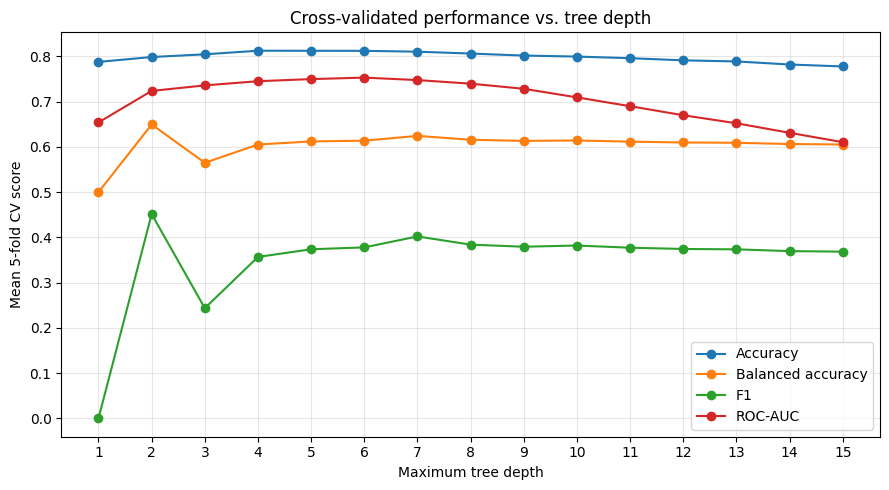

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_accuracy"],
    marker="o",
    label="Accuracy"
)

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_balanced_accuracy"],
    marker="o",
    label="Balanced accuracy"
)

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_f1"],
    marker="o",
    label="F1"
)

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_roc_auc"],
    marker="o",
    label="ROC-AUC"
)

ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("Mean 5-fold CV score")
ax.set_title("Cross-validated performance vs. tree depth")

ax.set_xticks(depth_values)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Saved: ../report/images/figure_04.png


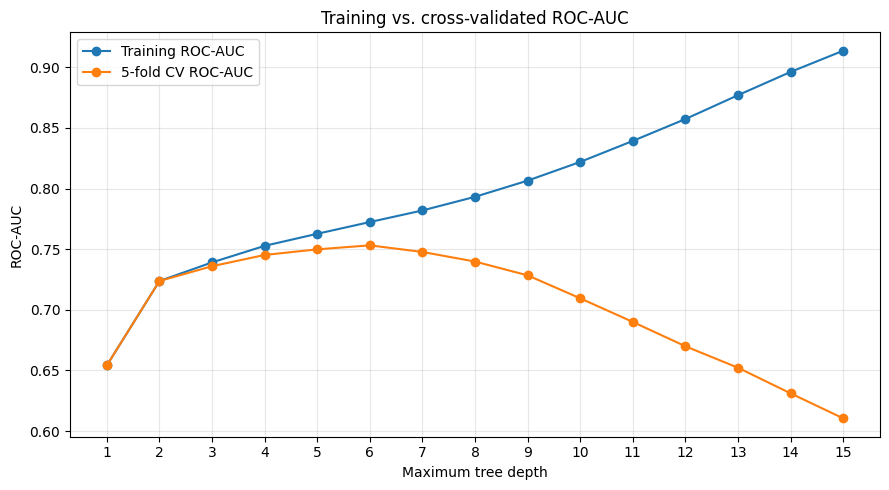

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    depth_results["max_depth"],
    depth_results["train_roc_auc"],
    marker="o",
    label="Training ROC-AUC"
)

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_roc_auc"],
    marker="o",
    label="5-fold CV ROC-AUC"
)

ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("ROC-AUC")
ax.set_title("Training vs. cross-validated ROC-AUC")

ax.set_xticks(depth_values)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Saved: ../report/images/figure_05.png


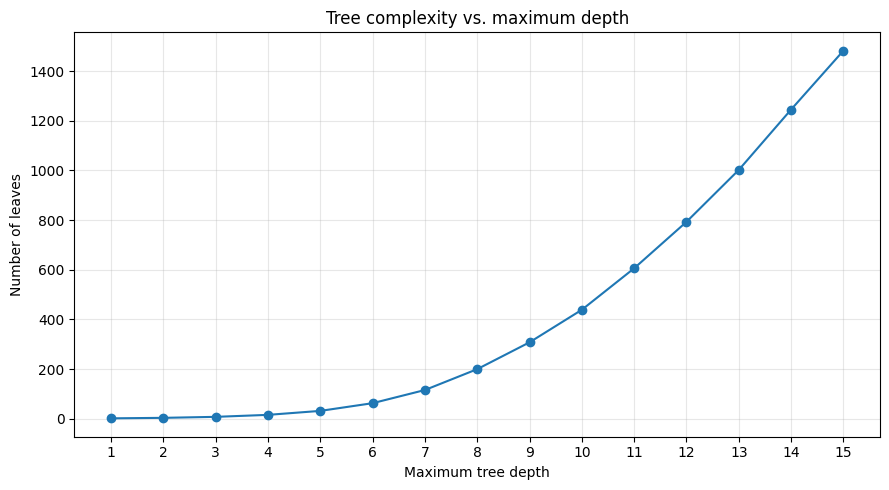

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    depth_results["max_depth"],
    depth_results["leaves"],
    marker="o"
)

ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("Number of leaves")
ax.set_title("Tree complexity vs. maximum depth")

ax.set_xticks(depth_values)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
best_auc_row = depth_results.loc[
    depth_results["cv_roc_auc"].idxmax()
]

best_balanced_acc_row = depth_results.loc[
    depth_results["cv_balanced_accuracy"].idxmax()
]

best_f1_row = depth_results.loc[
    depth_results["cv_f1"].idxmax()
]

print("Best depth by ROC-AUC:")
print(
    f"depth={int(best_auc_row['max_depth'])}, "
    f"ROC-AUC={best_auc_row['cv_roc_auc']:.4f}"
)

print("\nBest depth by balanced accuracy:")
print(
    f"depth={int(best_balanced_acc_row['max_depth'])}, "
    f"balanced accuracy="
    f"{best_balanced_acc_row['cv_balanced_accuracy']:.4f}"
)

print("\nBest depth by F1:")
print(
    f"depth={int(best_f1_row['max_depth'])}, "
    f"F1={best_f1_row['cv_f1']:.4f}"
)

Best depth by ROC-AUC:
depth=6, ROC-AUC=0.7532

Best depth by balanced accuracy:
depth=2, balanced accuracy=0.6496

Best depth by F1:
depth=2, F1=0.4515


## 4. Minimum leaf size and model complexity

Maximum depth controls how many consecutive decisions the tree can make, but
it does not directly prevent the model from creating leaves containing very
few observations.

We therefore study `min_samples_leaf`, which specifies the minimum number of
training observations that must remain in each terminal leaf.

Larger values can reduce overfitting and produce rules that apply to broader
groups of observations, potentially improving both generalization and
interpretability.

In [33]:
candidate_depths = [2, 3, 4, 5, 6]

min_leaf_values = [
    1,
    10,
    25,
    50,
    100,
    200,
    500
]

print("Candidate depths:", candidate_depths)
print("Minimum leaf sizes:", min_leaf_values)

Candidate depths: [2, 3, 4, 5, 6]
Minimum leaf sizes: [1, 10, 25, 50, 100, 200, 500]


In [34]:
leaf_results = []

for depth in candidate_depths:
    for min_leaf in min_leaf_values:

        model = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                (
                    "classifier",
                    DecisionTreeClassifier(
                        max_depth=depth,
                        min_samples_leaf=min_leaf,
                        random_state=RANDOM_STATE
                    )
                )
            ]
        )

        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )

        model.fit(X, y)

        fitted_tree = model.named_steps["classifier"]

        leaf_results.append({
            "max_depth": depth,
            "min_samples_leaf": min_leaf,

            "train_accuracy":
                scores["train_accuracy"].mean(),
            "cv_accuracy":
                scores["test_accuracy"].mean(),

            "train_balanced_accuracy":
                scores["train_balanced_accuracy"].mean(),
            "cv_balanced_accuracy":
                scores["test_balanced_accuracy"].mean(),

            "train_f1":
                scores["train_f1"].mean(),
            "cv_f1":
                scores["test_f1"].mean(),

            "train_roc_auc":
                scores["train_roc_auc"].mean(),
            "cv_roc_auc":
                scores["test_roc_auc"].mean(),

            "cv_roc_auc_std":
                scores["test_roc_auc"].std(),

            "actual_depth":
                fitted_tree.get_depth(),
            "leaves":
                fitted_tree.get_n_leaves(),
            "nodes":
                fitted_tree.tree_.node_count
        })

leaf_results = pd.DataFrame(leaf_results)

In [35]:
leaf_results[
    [
        "max_depth",
        "min_samples_leaf",
        "cv_accuracy",
        "cv_balanced_accuracy",
        "cv_f1",
        "cv_roc_auc",
        "cv_roc_auc_std",
        "actual_depth",
        "leaves",
        "nodes"
    ]
].sort_values(
    "cv_roc_auc",
    ascending=False
).round(4)

,max_depth,min_samples_leaf,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_roc_auc_std,actual_depth,leaves,nodes
32,6,100,0.8118,0.6091,0.3664,0.7573,0.0057,6,44,87
31,6,50,0.8114,0.6126,0.3753,0.7558,0.0063,6,46,91
33,6,200,0.8151,0.6163,0.3834,0.7558,0.0039,6,34,67
30,6,25,0.8107,0.6144,0.3800,0.7541,0.0054,6,55,109
29,6,10,0.8115,0.6139,0.3784,0.7538,0.0035,6,61,121
25,5,100,0.8120,0.6097,0.3677,0.7536,0.0050,5,28,55
26,5,200,0.8137,0.6084,0.3642,0.7532,0.0051,5,24,47
34,6,500,0.8133,0.6068,0.3598,0.7532,0.0035,6,23,45
28,6,1,0.8123,0.6138,0.3779,0.7532,0.0044,6,63,125
24,5,50,0.8123,0.6121,0.3736,0.7524,0.0054,5,30,59


In [36]:
auc_matrix = leaf_results.pivot(
    index="min_samples_leaf",
    columns="max_depth",
    values="cv_roc_auc"
)

auc_matrix.round(4)

max_depth,2,3,4,5,6
min_samples_leaf,,,,,
1,0.7237,0.7359,0.7452,0.7498,0.7532
10,0.7237,0.7359,0.7452,0.7499,0.7538
25,0.7237,0.7359,0.7449,0.7509,0.7541
50,0.7237,0.7361,0.7462,0.7524,0.7558
100,0.7237,0.7354,0.7470,0.7536,0.7573
200,0.7237,0.7355,0.7465,0.7532,0.7558
500,0.7237,0.7374,0.7462,0.7522,0.7532


Saved: ../report/images/figure_06.png


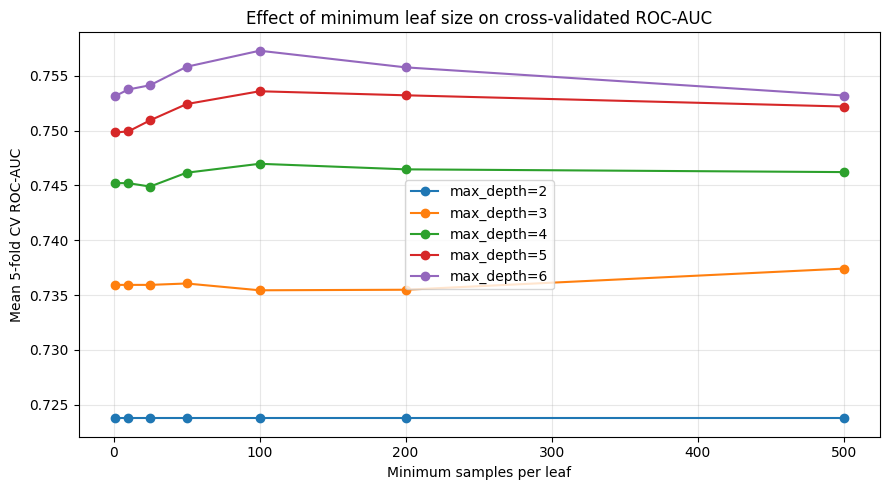

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

for depth in candidate_depths:
    subset = leaf_results[
        leaf_results["max_depth"] == depth
    ]

    ax.plot(
        subset["min_samples_leaf"],
        subset["cv_roc_auc"],
        marker="o",
        label=f"max_depth={depth}"
    )

ax.set_xlabel("Minimum samples per leaf")
ax.set_ylabel("Mean 5-fold CV ROC-AUC")
ax.set_title(
    "Effect of minimum leaf size on cross-validated ROC-AUC"
)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
top_models = (
    leaf_results[
        [
            "max_depth",
            "min_samples_leaf",
            "cv_accuracy",
            "cv_balanced_accuracy",
            "cv_f1",
            "cv_roc_auc",
            "cv_roc_auc_std",
            "leaves",
            "nodes"
        ]
    ]
    .sort_values(
        "cv_roc_auc",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

top_models.round(4)

,max_depth,min_samples_leaf,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_roc_auc_std,leaves,nodes
0,6,100,0.8118,0.6091,0.3664,0.7573,0.0057,44,87
1,6,50,0.8114,0.6126,0.3753,0.7558,0.0063,46,91
2,6,200,0.8151,0.6163,0.3834,0.7558,0.0039,34,67
3,6,25,0.8107,0.6144,0.3800,0.7541,0.0054,55,109
4,6,10,0.8115,0.6139,0.3784,0.7538,0.0035,61,121
5,5,100,0.8120,0.6097,0.3677,0.7536,0.0050,28,55
6,5,200,0.8137,0.6084,0.3642,0.7532,0.0051,24,47
7,6,500,0.8133,0.6068,0.3598,0.7532,0.0035,23,45
8,6,1,0.8123,0.6138,0.3779,0.7532,0.0044,63,125
9,5,50,0.8123,0.6121,0.3736,0.7524,0.0054,30,59


## 5. Feature selection and logical models

The complexity analysis shows a clear trade-off between predictive performance
and interpretability. Deeper trees achieve a higher cross-validated ROC-AUC,
with the best values obtained around a maximum depth of 6. However, these
models require substantially more nodes and leaves.

A maximum depth of 2 is selected to prioritize interpretability. The resulting
tree contains only 7 nodes and 4 terminal leaves, while achieving a mean
cross-validated accuracy of 0.7986, balanced accuracy of 0.6496, F1 score of
0.4515, and ROC-AUC of 0.7237.

Although its ROC-AUC is lower than that of the deeper alternatives, the
depth-2 tree achieves higher balanced accuracy and F1 score and is considerably
easier to inspect and explain. This trade-off is particularly relevant in the
context of explainable artificial intelligence.

For a maximum depth of 2, varying `min_samples_leaf` between 1 and 500 does not
change the cross-validation results or the resulting tree complexity. We retain
`min_samples_leaf=200` as a conservative constraint that prevents terminal
nodes from representing very small groups of observations.

Therefore, the complexity of the final CART model is fixed at:

- `max_depth = 2`
- `min_samples_leaf = 200`

With the complexity fixed, we now check whether all 15 predictors are actually
needed, or whether a smaller subset can provide comparable predictive
performance with a simpler representation.

### 5.1 Feature selection via cross-validation

We use forward selection, starting from an empty set. At each step, the predictor
that most improves the mean cross-validated ROC-AUC is added. Each candidate is
evaluated using the same stratified five-fold cross-validation strategy, and the
preprocessor is fitted independently within each training fold to avoid fitting
the model or preprocessing steps on validation data.

The search stops at the smallest number of predictors whose mean ROC-AUC is
within one standard error of the best value. A reduced subset is preferred when
its predictive performance is comparable to that of larger subsets, since a
tree that relies on fewer variables is generally easier to read and explain.
Interpretability is not guaranteed by a smaller feature count alone, but fewer
predictors reduce the number of variables involved in the learned decision rules.

Because the same cross-validation results are used both to guide feature
selection and to estimate the performance of the selected subset, the reported
cross-validated performance may be mildly optimistic. A nested cross-validation
procedure would provide a less biased estimate of the complete feature-selection
procedure, but was not considered necessary for this preliminary analysis.

Also, because some predictors are correlated
(`latest_repayment_status` and `payment_to_bill_ratio_6m`, for example), the
exact selected subset should not be interpreted as unique.

In [39]:
FINAL_MAX_DEPTH = 2
FINAL_MIN_SAMPLES_LEAF = 200


def make_preprocessor(columns):
    selected_cat = [c for c in categorical_features if c in columns]

    transformers = []

    if selected_cat:
        transformers.append(
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                selected_cat
            )
        )

    return ColumnTransformer(
        transformers,
        remainder="passthrough",
        verbose_feature_names_out=False
    )


def cv_roc_auc(columns):
    model = Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(columns)),
            (
                "classifier",
                DecisionTreeClassifier(
                    max_depth=FINAL_MAX_DEPTH,
                    min_samples_leaf=FINAL_MIN_SAMPLES_LEAF,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    scores = cross_validate(
        model,
        X[columns],
        y,
        cv=cv,
        scoring=["roc_auc"],
        n_jobs=-1
    )

    auc = scores["test_roc_auc"]

    return auc.mean(), auc.std() / np.sqrt(cv.n_splits)


selected_features = []
remaining_features = list(X.columns)
forward_results = []

while remaining_features:
    scored = [
        (cv_roc_auc(selected_features + [feature]), feature)
        for feature in remaining_features
    ]

    (mean_auc, se_auc), best_feature = max(
        scored,
        key=lambda item: item[0][0]
    )

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

    forward_results.append({
        "n_features": len(selected_features),
        "added_feature": best_feature,
        "cv_roc_auc": mean_auc,
        "cv_roc_auc_se": se_auc
    })

forward_results = pd.DataFrame(forward_results)

forward_results.round(4)


,n_features,added_feature,cv_roc_auc,cv_roc_auc_se
0,1,latest_repayment_status,0.6893,0.0040
1,2,payment_to_bill_ratio_6m,0.7237,0.0028
2,3,credit_limit,0.7237,0.0028
3,4,sex,0.7237,0.0028
4,5,education,0.7237,0.0028
5,6,marital_status,0.7237,0.0028
6,7,age,0.7237,0.0028
7,8,maximum_repayment_delay_6m,0.7237,0.0028
8,9,delayed_months_6m,0.7237,0.0028
9,10,average_bill_6m,0.7237,0.0028


Full model (15 predictors) mean ROC-AUC = 0.7237 (SE 0.0028), 
Best mean CV ROC-AUC: 0.7237 (SE 0.0028)
One-SE cutoff:        0.7210
Selected predictors:  2
Selected features:    ['latest_repayment_status', 'payment_to_bill_ratio_6m']
Saved: ../report/images/figure_07.png


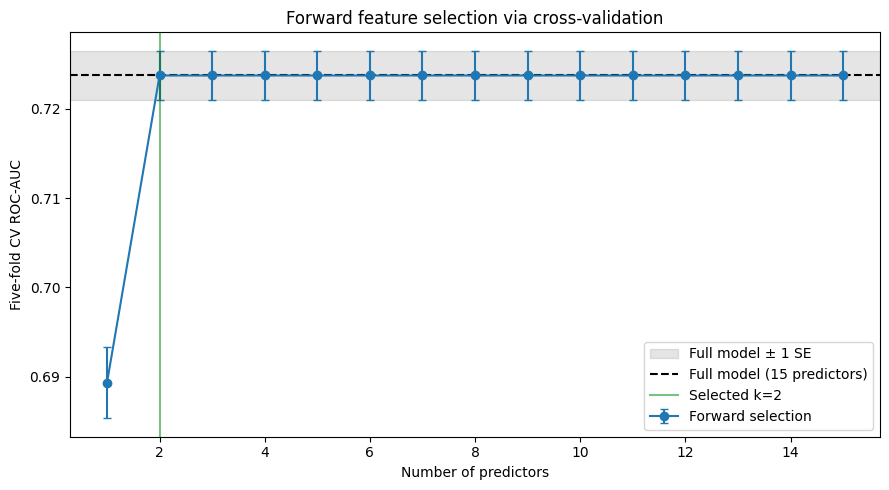

In [40]:
best_idx = forward_results["cv_roc_auc"].idxmax()
best_auc = forward_results.loc[best_idx, "cv_roc_auc"]
best_se = forward_results.loc[best_idx, "cv_roc_auc_se"]
cutoff = best_auc - best_se

within_one_se = forward_results[
    forward_results["cv_roc_auc"] >= cutoff
]

k_star = int(within_one_se["n_features"].min())

SELECTED_FEATURES = forward_results.loc[
    :k_star - 1,
    "added_feature"
].tolist()

full_auc = forward_results.iloc[-1]["cv_roc_auc"]
full_se = forward_results.iloc[-1]["cv_roc_auc_se"]

print(f"Full model (15 predictors) mean ROC-AUC = {full_auc:.4f} (SE {full_se:.4f}), ")
print(f"Best mean CV ROC-AUC: {best_auc:.4f} (SE {best_se:.4f})")
print(f"One-SE cutoff:        {cutoff:.4f}")
print(f"Selected predictors:  {k_star}")
print(f"Selected features:    {SELECTED_FEATURES}")



fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    forward_results["n_features"],
    forward_results["cv_roc_auc"],
    yerr=forward_results["cv_roc_auc_se"],
    marker="o",
    capsize=3,
    label="Forward selection"
)

ax.axhspan(
    full_auc - full_se,
    full_auc + full_se,
    color="black",
    alpha=0.10,
    label="Full model ± 1 SE"
)

ax.axhline(
    full_auc,
    linestyle="--",
    color="black",
    label=f"Full model ({forward_results['n_features'].max()} predictors)"
)

ax.axvline(
    k_star,
    linestyle="-",
    color="green",
    alpha=0.5,
    label=f"Selected k={k_star}"
)

ax.set_xlabel("Number of predictors")
ax.set_ylabel("Five-fold CV ROC-AUC")
ax.set_title("Forward feature selection via cross-validation")
ax.legend()

plt.tight_layout()
plt.show()


### 5.2 Final CART model

The final CART model is refitted using only the predictors selected in the
previous step, while keeping the previously selected complexity constraints
fixed (`max_depth = 2`, `min_samples_leaf = 200`).

Forward selection retains two predictors:

- `latest_repayment_status`;
- `payment_to_bill_ratio_6m`.

The resulting model has a depth of 2, with 7 nodes and 4 terminal leaves.
Its small size allows the complete decision structure to be inspected directly,
which is particularly useful for the subsequent global and local interpretation.

All subsequent CART results refer to this reduced model.

In [41]:
final_model = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(SELECTED_FEATURES)),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=FINAL_MAX_DEPTH,
                min_samples_leaf=FINAL_MIN_SAMPLES_LEAF,
                random_state=RANDOM_STATE
            )
        )
    ]
)

final_model.fit(X[SELECTED_FEATURES], y)

final_model


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,[]
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [42]:
final_cv = cross_validate(
    final_model,
    X[SELECTED_FEATURES],
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

final_cv_results = pd.DataFrame(final_cv)

final_summary = pd.DataFrame({
    "metric": [
        "accuracy",
        "balanced_accuracy",
        "f1",
        "roc_auc"
    ],
    "train_mean": [
        final_cv_results["train_accuracy"].mean(),
        final_cv_results["train_balanced_accuracy"].mean(),
        final_cv_results["train_f1"].mean(),
        final_cv_results["train_roc_auc"].mean()
    ],
    "cv_mean": [
        final_cv_results["test_accuracy"].mean(),
        final_cv_results["test_balanced_accuracy"].mean(),
        final_cv_results["test_f1"].mean(),
        final_cv_results["test_roc_auc"].mean()
    ],
    "cv_std": [
        final_cv_results["test_accuracy"].std(),
        final_cv_results["test_balanced_accuracy"].std(),
        final_cv_results["test_f1"].std(),
        final_cv_results["test_roc_auc"].std()
    ]
})

final_summary.round(4)

,metric,train_mean,cv_mean,cv_std
0,accuracy,0.7986,0.7986,0.0037
1,balanced_accuracy,0.6496,0.6496,0.0046
2,f1,0.4515,0.4515,0.0084
3,roc_auc,0.7237,0.7237,0.0069


In [43]:
final_tree = final_model.named_steps["classifier"]

print(f"Tree depth:       {final_tree.get_depth()}")
print(f"Number of leaves: {final_tree.get_n_leaves()}")
print(f"Number of nodes:  {final_tree.tree_.node_count}")

Tree depth:       2
Number of leaves: 4
Number of nodes:  7


In [44]:
fitted_preprocessor = final_model.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

print(f"Number of transformed features: {len(feature_names)}")

feature_names

Number of transformed features: 2


array(['latest_repayment_status', 'payment_to_bill_ratio_6m'],
      dtype=object)

In [45]:
feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": final_tree.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,latest_repayment_status,0.655173
1,payment_to_bill_ratio_6m,0.344827


In [46]:
used_features = feature_importance[
    feature_importance["importance"] > 0
].copy()

used_features

,feature,importance
0,latest_repayment_status,0.655173
1,payment_to_bill_ratio_6m,0.344827


Saved: ../report/images/figure_08.png


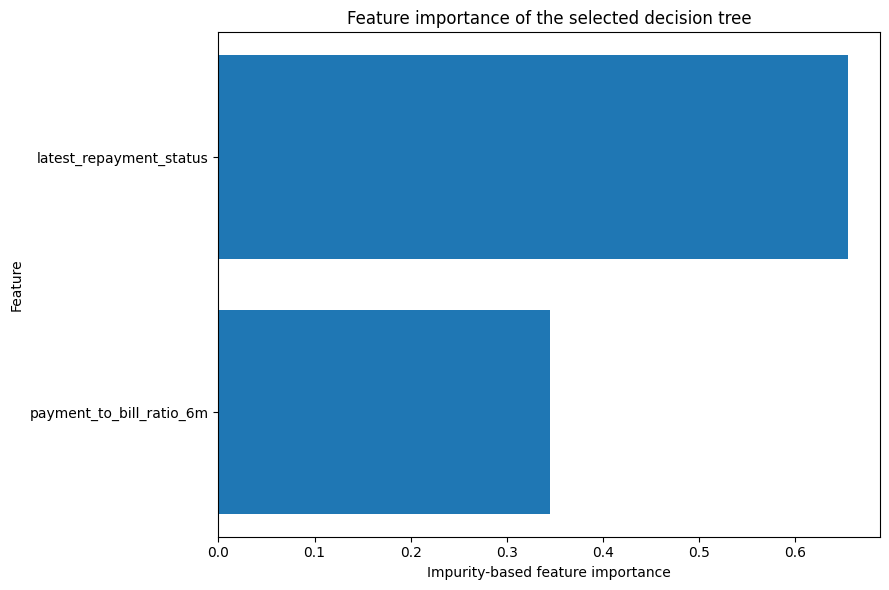

In [47]:
fig, ax = plt.subplots(figsize=(9, 6))

plot_data = used_features.sort_values(
    "importance",
    ascending=True
)

ax.barh(
    plot_data["feature"],
    plot_data["importance"]
)

ax.set_xlabel("Impurity-based feature importance")
ax.set_ylabel("Feature")
ax.set_title("Feature importance of the selected decision tree")

plt.tight_layout()
plt.show()

Saved: ../report/images/figure_09.png


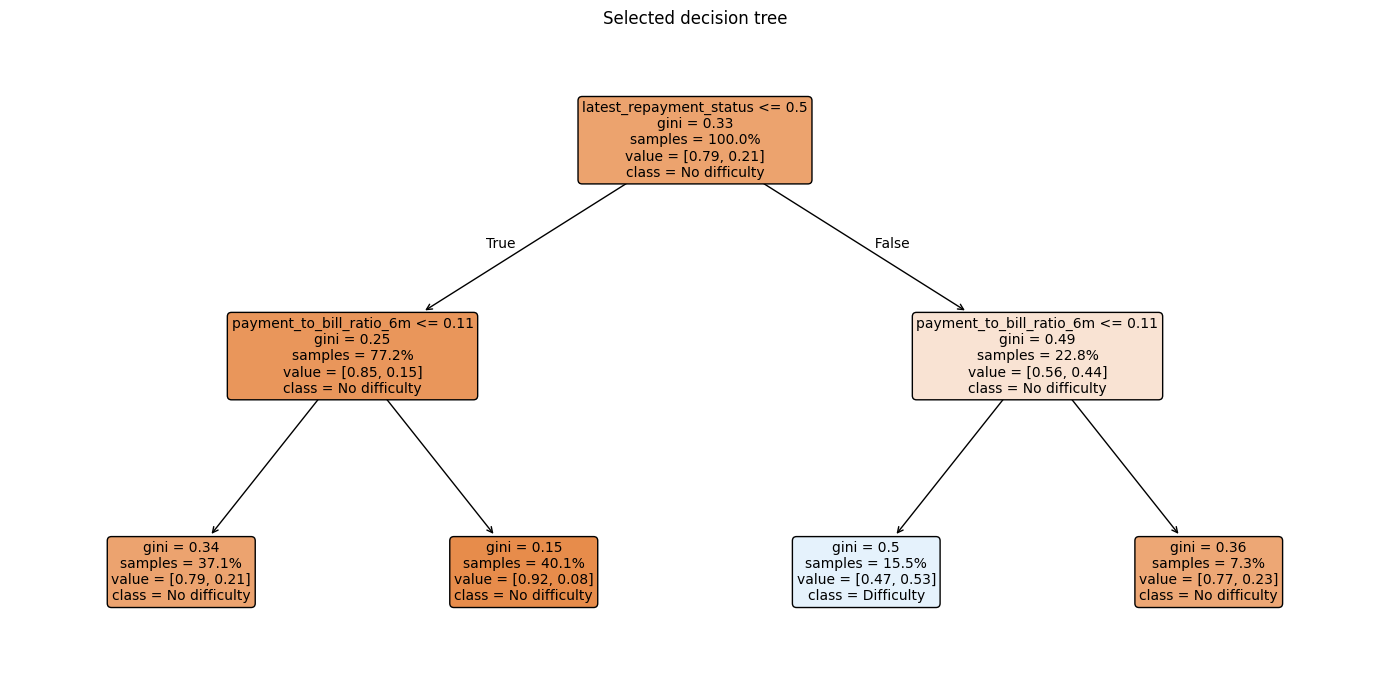

In [48]:
fig, ax = plt.subplots(figsize=(14, 7))

plot_tree(
    final_tree,
    feature_names=feature_names,
    class_names=[
        "No difficulty",
        "Difficulty"
    ],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    fontsize=10,
    ax=ax
)

plt.title("Selected decision tree")

plt.tight_layout()
plt.show()

In [49]:
tree_rules = export_text(
    final_tree,
    feature_names=list(feature_names),
    decimals=3
)

print(tree_rules)

|--- latest_repayment_status <= 0.500
|   |--- payment_to_bill_ratio_6m <= 0.105
|   |   |--- class: 0
|   |--- payment_to_bill_ratio_6m >  0.105
|   |   |--- class: 0
|--- latest_repayment_status >  0.500
|   |--- payment_to_bill_ratio_6m <= 0.105
|   |   |--- class: 1
|   |--- payment_to_bill_ratio_6m >  0.105
|   |   |--- class: 0



In [50]:
tree_structure = final_tree.tree_

leaf_nodes = np.where(
    tree_structure.children_left == tree_structure.children_right
)[0]

leaf_data = []

for node_id in leaf_nodes:
    class_counts = tree_structure.value[node_id][0]
    total = class_counts.sum()

    probability_class_1 = (
        class_counts[1] / total
        if total > 0
        else 0
    )

    leaf_data.append({
        "node_id": node_id,
        "samples": tree_structure.n_node_samples[node_id],
        "class_0": class_counts[0],
        "class_1": class_counts[1],
        "probability_class_1": probability_class_1,
        "predicted_class": int(np.argmax(class_counts))
    })

leaf_summary = (
    pd.DataFrame(leaf_data)
    .sort_values(
        "probability_class_1",
        ascending=False
    )
    .reset_index(drop=True)
)

leaf_summary.round(4)

,node_id,samples,class_0,class_1,probability_class_1,predicted_class
0,5,3875,0.4653,0.5347,0.5347,1
1,6,1820,0.7670,0.2330,0.2330,0
2,2,9278,0.7853,0.2147,0.2147,0
3,3,10027,0.9187,0.0813,0.0813,0


In [51]:
leaf_summary.head(10).round(4)

,node_id,samples,class_0,class_1,probability_class_1,predicted_class
0,5,3875,0.4653,0.5347,0.5347,1
1,6,1820,0.7670,0.2330,0.2330,0
2,2,9278,0.7853,0.2147,0.2147,0
3,3,10027,0.9187,0.0813,0.0813,0


In [52]:
leaf_summary.tail(10).sort_values(
    "probability_class_1"
).round(4)

,node_id,samples,class_0,class_1,probability_class_1,predicted_class
3,3,10027,0.9187,0.0813,0.0813,0
2,2,9278,0.7853,0.2147,0.2147,0
1,6,1820,0.7670,0.2330,0.2330,0
0,5,3875,0.4653,0.5347,0.5347,1


In [53]:
def get_leaf_rule(tree, feature_names, target_node):
    """
    Devuelve la secuencia de decisiones desde la raíz
    hasta una hoja concreta.
    """

    tree_structure = tree.tree_
    path = []

    def recurse(node_id, current_path):
        if node_id == target_node:
            path.extend(current_path)
            return True

        left_child = tree_structure.children_left[node_id]
        right_child = tree_structure.children_right[node_id]

        # Si estamos en una hoja, no podemos continuar
        if left_child == right_child:
            return False

        feature = feature_names[
            tree_structure.feature[node_id]
        ]
        threshold = tree_structure.threshold[node_id]

        # Buscar por la rama izquierda
        if recurse(
            left_child,
            current_path + [
                f"{feature} <= {threshold:.3f}"
            ]
        ):
            return True

        # Buscar por la rama derecha
        if recurse(
            right_child,
            current_path + [
                f"{feature} > {threshold:.3f}"
            ]
        ):
            return True

        return False

    recurse(0, [])

    return path

In [54]:
highest_risk_leaf = int(
    leaf_summary.iloc[0]["node_id"]
)

highest_risk_rule = get_leaf_rule(
    final_tree,
    feature_names,
    highest_risk_leaf
)

print(
    f"Highest-risk leaf: "
    f"{highest_risk_leaf}"
)

print(
    f"Estimated probability of class 1: "
    f"{leaf_summary.iloc[0]['probability_class_1']:.3f}"
)

print(
    f"Training samples in leaf: "
    f"{int(leaf_summary.iloc[0]['samples'])}"
)

print("\nRule:")

for condition in highest_risk_rule:
    print(f"  {condition}")

Highest-risk leaf: 5
Estimated probability of class 1: 0.535
Training samples in leaf: 3875

Rule:
  latest_repayment_status > 0.500
  payment_to_bill_ratio_6m <= 0.105


In [55]:
lowest_risk_leaf = int(
    leaf_summary.iloc[-1]["node_id"]
)

lowest_risk_rule = get_leaf_rule(
    final_tree,
    feature_names,
    lowest_risk_leaf
)

print(
    f"Lowest-risk leaf: "
    f"{lowest_risk_leaf}"
)

print(
    f"Estimated probability of class 1: "
    f"{leaf_summary.iloc[-1]['probability_class_1']:.3f}"
)

print(
    f"Training samples in leaf: "
    f"{int(leaf_summary.iloc[-1]['samples'])}"
)

print("\nRule:")

for condition in lowest_risk_rule:
    print(f"  {condition}")

Lowest-risk leaf: 3
Estimated probability of class 1: 0.081
Training samples in leaf: 10027

Rule:
  latest_repayment_status <= 0.500
  payment_to_bill_ratio_6m > 0.105


Saved: ../report/images/figure_10.png


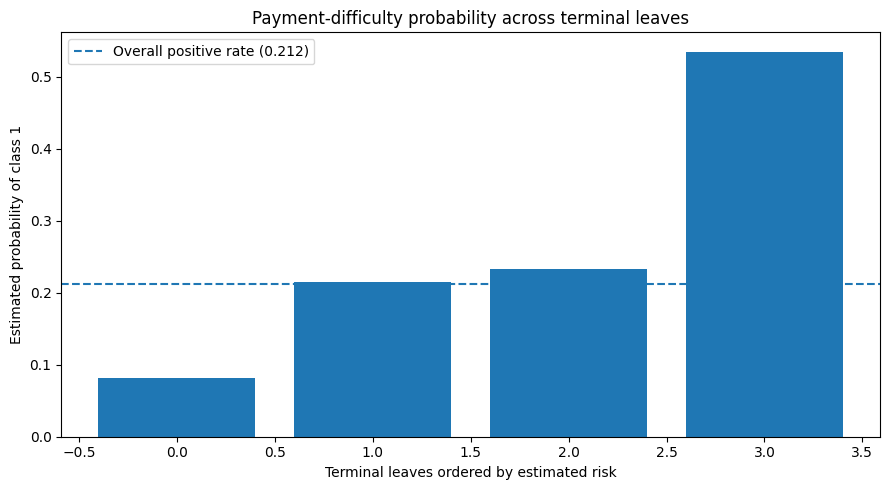

In [56]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_leaf_data = leaf_summary.sort_values(
    "probability_class_1"
).reset_index(drop=True)

ax.bar(
    range(len(plot_leaf_data)),
    plot_leaf_data["probability_class_1"]
)

ax.axhline(
    y=y.mean(),
    linestyle="--",
    label=f"Overall positive rate ({y.mean():.3f})"
)

ax.set_xlabel("Terminal leaves ordered by estimated risk")
ax.set_ylabel("Estimated probability of class 1")
ax.set_title(
    "Payment-difficulty probability across terminal leaves"
)

ax.legend()

plt.tight_layout()
plt.show()

### 5.3 Optimal Sparse Decision Tree (GOSDT)

The previous model is based on CART, which constructs a decision tree using a
greedy top-down procedure. Although restricting its depth and minimum leaf size
reduces overfitting and improves interpretability, the resulting tree is not
guaranteed to be globally optimal.

As an additional logical model, we evaluate the Generalized Optimal Sparse
Decision Tree (GOSDT). GOSDT searches for a sparse decision tree by jointly
considering predictive error and model complexity rather than greedily selecting
one split at a time.

The objective is not simply to obtain higher predictive performance, but to
investigate whether a globally optimized sparse tree can provide a more compact
and interpretable alternative to the CART model.

In [57]:
from gosdt import GOSDTClassifier, ThresholdGuessBinarizer
from sklearn.ensemble import GradientBoostingClassifier
import time

GOSDT_REGULARIZATION_GRID = [
    0.0005,
    0.001,
    0.005,
    0.01
]

GOSDT_DEPTH_BUDGET = 6
GOSDT_TIME_LIMIT = 120

In [58]:
X_gosdt = X[SELECTED_FEATURES].copy()
y_gosdt = y.copy()

print("Original shape:", X_gosdt.shape)

Original shape: (25000, 2)


#### 5.3.1 Regularization selection

The GOSDT regularization parameter controls the trade-off between predictive
error and tree complexity. Larger values penalize additional leaves more
strongly and therefore favor smaller trees.

We select the regularization parameter using the same stratified five-fold
cross-validation strategy. All preprocessing, threshold generation, and
reference-model fitting are performed independently within each training fold
to avoid information leakage.

Balanced accuracy is used as the selection criterion because the target is
imbalanced and accuracy alone may favor the majority class.

In [59]:
gosdt_reg_results = []

for regularization in GOSDT_REGULARIZATION_GRID:

    fold_scores = []

    print(f"Regularization = {regularization}")

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X_gosdt, y_gosdt),
        start=1
    ):
        X_train_fold = X_gosdt.iloc[train_idx]
        X_val_fold = X_gosdt.iloc[val_idx]

        y_train_fold = y_gosdt.iloc[train_idx]
        y_val_fold = y_gosdt.iloc[val_idx]

        # Preprocessing
        fold_preprocessor = make_preprocessor(SELECTED_FEATURES)

        X_train_encoded = fold_preprocessor.fit_transform(
            X_train_fold
        )
        X_val_encoded = fold_preprocessor.transform(
            X_val_fold
        )

        feature_names = fold_preprocessor.get_feature_names_out()

        X_train_encoded = pd.DataFrame(
            X_train_encoded,
            columns=feature_names,
            index=X_train_fold.index
        )

        X_val_encoded = pd.DataFrame(
            X_val_encoded,
            columns=feature_names,
            index=X_val_fold.index
        )

        # Threshold generation
        fold_binarizer = ThresholdGuessBinarizer(
            n_estimators=40,
            max_depth=1,
            random_state=RANDOM_STATE
        )

        fold_binarizer.set_output(transform="pandas")

        X_train_binary = fold_binarizer.fit_transform(
            X_train_encoded,
            y_train_fold
        )

        X_val_binary = fold_binarizer.transform(
            X_val_encoded
        )

        # Reference model
        fold_reference = GradientBoostingClassifier(
            n_estimators=40,
            max_depth=1,
            random_state=RANDOM_STATE
        )

        fold_reference.fit(
            X_train_binary,
            y_train_fold
        )

        reference_labels_fold = fold_reference.predict(
            X_train_binary
        )

        # GOSDT
        fold_model = GOSDTClassifier(
            regularization=regularization,
            depth_budget=GOSDT_DEPTH_BUDGET,
            time_limit=GOSDT_TIME_LIMIT,
            similar_support=False,
            verbose=False
        )

        fold_model.fit(
            X_train_binary,
            y_train_fold,
            y_ref=reference_labels_fold
        )

        y_pred = np.asarray(
            fold_model.predict(X_val_binary)
        ).reshape(-1)

        fold_scores.append({
            "balanced_accuracy":
                balanced_accuracy_score(y_val_fold, y_pred),
            "f1":
                f1_score(y_val_fold, y_pred),
            "accuracy":
                accuracy_score(y_val_fold, y_pred)
        })

    fold_scores = pd.DataFrame(fold_scores)

    gosdt_reg_results.append({
        "regularization": regularization,
        "accuracy_mean": fold_scores["accuracy"].mean(),
        "balanced_accuracy_mean":
            fold_scores["balanced_accuracy"].mean(),
        "f1_mean": fold_scores["f1"].mean(),
        "balanced_accuracy_std":
            fold_scores["balanced_accuracy"].std()
    })

gosdt_reg_results = pd.DataFrame(gosdt_reg_results)

display(
    gosdt_reg_results
    .sort_values("balanced_accuracy_mean", ascending=False)
    .round(4)
)

Regularization = 0.0005
Regularization = 0.001
Regularization = 0.005
Regularization = 0.01


,regularization,accuracy_mean,balanced_accuracy_mean,f1_mean,balanced_accuracy_std
0,0.0005,0.8068,0.6209,0.3955,0.0055
1,0.0010,0.8068,0.6209,0.3955,0.0055
2,0.0050,0.7969,0.5659,0.2557,0.0057
3,0.0100,0.7893,0.5118,0.0471,0.0264


In [60]:
best_gosdt_row = gosdt_reg_results.loc[
    gosdt_reg_results["balanced_accuracy_mean"].idxmax()
]

GOSDT_REGULARIZATION = float(
    best_gosdt_row["regularization"]
)

print(
    f"Selected regularization: "
    f"{GOSDT_REGULARIZATION}"
)

print(
    f"Mean CV balanced accuracy: "
    f"{best_gosdt_row['balanced_accuracy_mean']:.4f}"
)

Selected regularization: 0.0005
Mean CV balanced accuracy: 0.6209


In [61]:
gosdt_preprocessor = make_preprocessor(SELECTED_FEATURES)

X_gosdt_encoded = gosdt_preprocessor.fit_transform(X_gosdt)

X_gosdt_encoded = pd.DataFrame(
    X_gosdt_encoded,
    columns=gosdt_preprocessor.get_feature_names_out(),
    index=X_gosdt.index
)

print("Original shape:", X_gosdt.shape)
print("Encoded shape:", X_gosdt_encoded.shape)

Original shape: (25000, 2)
Encoded shape: (25000, 2)


In [62]:
threshold_binarizer = ThresholdGuessBinarizer(
    n_estimators=40,
    max_depth=1,
    random_state=RANDOM_STATE
)

threshold_binarizer.set_output(transform="pandas")

X_gosdt_binary = threshold_binarizer.fit_transform(
    X_gosdt_encoded,
    y_gosdt
)

print("Encoded shape:", X_gosdt_encoded.shape)
print("Binarized shape:", X_gosdt_binary.shape)

display(X_gosdt_binary.head())

Encoded shape: (25000, 2)
Binarized shape: (25000, 9)


,latest_repayment_status <= 0.5,latest_repayment_status <= 1.5,payment_to_bill_ratio_6m <= 0.024999999441206455,payment_to_bill_ratio_6m <= 0.03499999921768904,payment_to_bill_ratio_6m <= 0.0950000025331974,payment_to_bill_ratio_6m <= 0.10500000044703484,payment_to_bill_ratio_6m <= 0.11499999836087227,payment_to_bill_ratio_6m <= 0.24499999731779099,latest_repayment_status <= 2.5
0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0


In [63]:
print(X_gosdt_encoded.dtypes)
print(
    "All columns numeric:",
    all(pd.api.types.is_numeric_dtype(dtype)
        for dtype in X_gosdt_encoded.dtypes)
)

latest_repayment_status     float64
payment_to_bill_ratio_6m    float64
dtype: object
All columns numeric: True


In [64]:
reference_model = GradientBoostingClassifier(
    n_estimators=40,
    max_depth=1,
    random_state=RANDOM_STATE
)

reference_model.fit(
    X_gosdt_binary,
    y_gosdt
)

reference_labels = reference_model.predict(
    X_gosdt_binary
)

print(
    f"Reference model accuracy: "
    f"{accuracy_score(y_gosdt, reference_labels):.4f}"
)

print(
    f"Reference predicted positive rate: "
    f"{reference_labels.mean():.4f}"
)

Reference model accuracy: 0.8044
Reference predicted positive rate: 0.0418


In [65]:
gosdt_model = GOSDTClassifier(
    regularization=GOSDT_REGULARIZATION,
    depth_budget=GOSDT_DEPTH_BUDGET,
    time_limit=GOSDT_TIME_LIMIT,
    similar_support=False,
    verbose=False
)

start_time = time.perf_counter()

gosdt_model.fit(
    X_gosdt_binary,
    y_gosdt,
    y_ref=reference_labels
)

gosdt_training_time = time.perf_counter() - start_time

gosdt_predictions = np.asarray(
    gosdt_model.predict(X_gosdt_binary)
).reshape(-1)

print(f"Training time: {gosdt_training_time:.2f} seconds")
print(
    f"Training accuracy: "
    f"{accuracy_score(y_gosdt, gosdt_predictions):.4f}"
)
print(
    f"Training balanced accuracy: "
    f"{balanced_accuracy_score(y_gosdt, gosdt_predictions):.4f}"
)
print(
    f"Training F1: "
    f"{f1_score(y_gosdt, gosdt_predictions):.4f}"
)
print(
    f"Predicted positive rate: "
    f"{gosdt_predictions.mean():.4f}"
)

Training time: 0.03 seconds
Training accuracy: 0.8068
Training balanced accuracy: 0.6204
Training F1: 0.3944
Predicted positive rate: 0.1069


In [66]:
print(gosdt_model.trees_[0])

<class 'gosdt._tree.Tree'>: { feature: 1 [ left child: { feature: 0 [ left child: { prediction: 0, loss: 0.1122799962759018 }, right child: { feature: 2 [ left child: { prediction: 1, loss: 0.008799999952316284 }, right child: { prediction: 0, loss: 0.030319999903440475 }] }] }, right child: { feature: 4 [ left child: { prediction: 1, loss: 0.03519999980926514 }, right child: { prediction: 0, loss: 0.006599999964237213 }] }] }, Index(['latest_repayment_status <= 0.5', 'latest_repayment_status <= 1.5',
       'payment_to_bill_ratio_6m <= 0.024999999441206455',
       'payment_to_bill_ratio_6m <= 0.03499999921768904',
       'payment_to_bill_ratio_6m <= 0.0950000025331974',
       'payment_to_bill_ratio_6m <= 0.10500000044703484',
       'payment_to_bill_ratio_6m <= 0.11499999836087227',
       'payment_to_bill_ratio_6m <= 0.24499999731779099',
       'latest_repayment_status <= 2.5'],
      dtype='object'), 2


#### 5.3.2 Structure of the final GOSDT model

After selecting the regularization parameter by five-fold cross-validation, we
inspect the structure of the final GOSDT model.

Although the optimization allows a maximum depth of 6, this value represents
only a search budget and does not force the resulting tree to reach that depth.
The learned sparse tree has an effective depth of 3, with 4 decision nodes and
5 terminal leaves.

The model uses thresholded versions of the same two original predictors selected
for CART: `latest_repayment_status` and `payment_to_bill_ratio_6m`. Therefore,
the complete GOSDT tree remains small enough to inspect directly and to compare
with the CART model.

For comparison, the final CART model has an effective depth of 2, with 3
decision nodes, 4 leaves and 7 total nodes. Therefore, both logical models
remain sufficiently compact for direct inspection, although CART produces the
smaller structure.

Effective depth: 3
Decision nodes:  4
Leaves:          5
Total nodes:     9


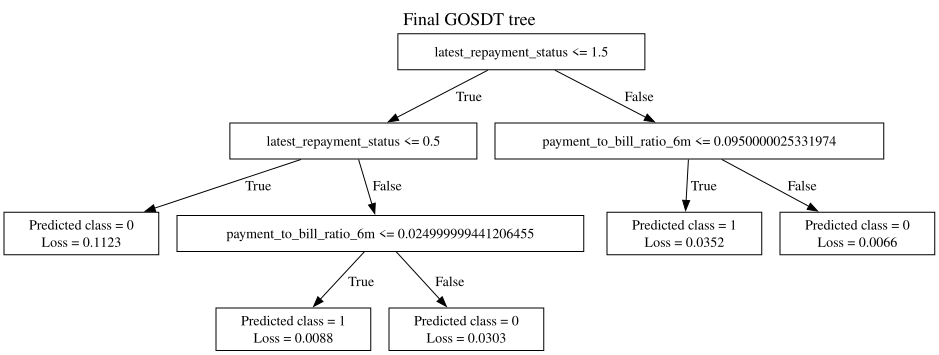

In [67]:
gosdt_tree = gosdt_model.trees_[0]


def is_gosdt_leaf(node):
    return hasattr(node, "prediction")


def gosdt_node_stats(node, depth=0):
    """Compute structural statistics of the GOSDT tree."""

    if is_gosdt_leaf(node):
        return depth, 0, 1

    left_depth, left_decisions, left_leaves = gosdt_node_stats(
        node.left_child,
        depth + 1
    )

    right_depth, right_decisions, right_leaves = gosdt_node_stats(
        node.right_child,
        depth + 1
    )

    return (
        max(left_depth, right_depth),
        1 + left_decisions + right_decisions,
        left_leaves + right_leaves
    )


def add_gosdt_node(dot, node, counter):
    """Recursively add GOSDT nodes to a Graphviz graph."""

    node_id = str(counter[0])
    counter[0] += 1

    # Leaf
    if is_gosdt_leaf(node):
        dot.node(
            node_id,
            label=(
                f"Predicted class = {int(node.prediction)}\n"
                f"Loss = {float(node.loss):.4f}"
            ),
            shape="box"
        )

        return node_id

    # Decision node
    feature_name = str(
        gosdt_tree.features[int(node.feature)]
    )

    dot.node(
        node_id,
        label=feature_name,
        shape="box"
    )

    left_id = add_gosdt_node(
        dot,
        node.left_child,
        counter
    )

    right_id = add_gosdt_node(
        dot,
        node.right_child,
        counter
    )

    dot.edge(node_id, left_id, label="True")
    dot.edge(node_id, right_id, label="False")

    return node_id


# Structural statistics
gosdt_depth, gosdt_decision_nodes, gosdt_leaves = gosdt_node_stats(
    gosdt_tree.tree
)

gosdt_total_nodes = gosdt_decision_nodes + gosdt_leaves

print(f"Effective depth: {gosdt_depth}")
print(f"Decision nodes:  {gosdt_decision_nodes}")
print(f"Leaves:          {gosdt_leaves}")
print(f"Total nodes:     {gosdt_total_nodes}")


# Visualization
gosdt_graph = Digraph(
    "GOSDT",
    format="png"
)

gosdt_graph.attr(
    rankdir="TB",
    label="Final GOSDT tree",
    labelloc="t",
    fontsize="18"
)

add_gosdt_node(
    gosdt_graph,
    gosdt_tree.tree,
    [0]
)

display(gosdt_graph)

In [68]:
def get_gosdt_original_features(node):
    """Return the original predictors used by GOSDT."""

    if is_gosdt_leaf(node):
        return set()

    feature_name = str(
        gosdt_tree.features[int(node.feature)]
    )

    original_feature = feature_name.split(" <= ")[0]

    return (
        {original_feature}
        | get_gosdt_original_features(node.left_child)
        | get_gosdt_original_features(node.right_child)
    )


gosdt_original_features = get_gosdt_original_features(
    gosdt_tree.tree
)

cart_leaves = final_tree.get_n_leaves()
cart_total_nodes = final_tree.tree_.node_count
cart_decision_nodes = cart_total_nodes - cart_leaves


structural_comparison = pd.DataFrame({
    "Classifier": [
        "CART",
        "GOSDT"
    ],
    "Effective depth": [
        final_tree.get_depth(),
        gosdt_depth
    ],
    "Decision nodes": [
        cart_decision_nodes,
        gosdt_decision_nodes
    ],
    "Leaves": [
        cart_leaves,
        gosdt_leaves
    ],
    "Total nodes": [
        cart_total_nodes,
        gosdt_total_nodes
    ],
    "Original features used": [
        len(SELECTED_FEATURES),
        len(gosdt_original_features)
    ]
})

print(
    "Original features used by GOSDT:",
    sorted(gosdt_original_features)
)

display(structural_comparison)

Original features used by GOSDT: ['latest_repayment_status', 'payment_to_bill_ratio_6m']


,Classifier,Effective depth,Decision nodes,Leaves,Total nodes,Original features used
0,CART,2,3,4,7,2
1,GOSDT,3,4,5,9,2


#### 5.3.3 Five-fold cross-validation

To obtain a comparable estimate of generalization performance, GOSDT is
evaluated using the same stratified five-fold cross-validation strategy used
for CART.

All preprocessing steps, including categorical encoding and threshold
generation, are fitted independently within each training fold to prevent
information leakage from the validation data.

In [69]:
gosdt_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_gosdt, y_gosdt),
    start=1
):
    print(f"Fold {fold}/5")

    X_train_fold = X_gosdt.iloc[train_idx]
    X_val_fold = X_gosdt.iloc[val_idx]

    y_train_fold = y_gosdt.iloc[train_idx]
    y_val_fold = y_gosdt.iloc[val_idx]

    # 1. Categorical preprocessing
    fold_preprocessor = make_preprocessor(SELECTED_FEATURES)

    X_train_encoded = fold_preprocessor.fit_transform(X_train_fold)
    X_val_encoded = fold_preprocessor.transform(X_val_fold)

    feature_names = fold_preprocessor.get_feature_names_out()

    X_train_encoded = pd.DataFrame(
        X_train_encoded,
        columns=feature_names,
        index=X_train_fold.index
    )

    X_val_encoded = pd.DataFrame(
        X_val_encoded,
        columns=feature_names,
        index=X_val_fold.index
    )

    # 2. Threshold generation
    fold_binarizer = ThresholdGuessBinarizer(
        n_estimators=40,
        max_depth=1,
        random_state=RANDOM_STATE
    )

    fold_binarizer.set_output(transform="pandas")

    X_train_binary = fold_binarizer.fit_transform(
        X_train_encoded,
        y_train_fold
    )

    X_val_binary = fold_binarizer.transform(
        X_val_encoded
    )

    # 3. Reference model
    fold_reference = GradientBoostingClassifier(
        n_estimators=40,
        max_depth=1,
        random_state=RANDOM_STATE
    )

    fold_reference.fit(
        X_train_binary,
        y_train_fold
    )

    reference_labels_fold = fold_reference.predict(
        X_train_binary
    )

    # 4. GOSDT
    fold_gosdt = GOSDTClassifier(
        regularization=GOSDT_REGULARIZATION,
        depth_budget=GOSDT_DEPTH_BUDGET,
        time_limit=GOSDT_TIME_LIMIT,
        similar_support=False,
        verbose=False
    )

    start_time = time.perf_counter()

    fold_gosdt.fit(
        X_train_binary,
        y_train_fold,
        y_ref=reference_labels_fold
    )

    elapsed = time.perf_counter() - start_time

    # 5. Validation predictions
    y_pred = np.asarray(
        fold_gosdt.predict(X_val_binary)
    ).reshape(-1)

    gosdt_cv_results.append({
        "fold": fold,
        "accuracy": accuracy_score(y_val_fold, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_val_fold, y_pred
        ),
        "f1": f1_score(y_val_fold, y_pred),
        "predicted_positive_rate": y_pred.mean(),
        "training_time": elapsed
    })

    print(
        f"  Accuracy: {gosdt_cv_results[-1]['accuracy']:.4f} | "
        f"Balanced accuracy: "
        f"{gosdt_cv_results[-1]['balanced_accuracy']:.4f} | "
        f"F1: {gosdt_cv_results[-1]['f1']:.4f} | "
        f"Time: {elapsed:.2f}s"
    )

Fold 1/5
  Accuracy: 0.8120 | Balanced accuracy: 0.6266 | F1: 0.4073 | Time: 0.03s
Fold 2/5
  Accuracy: 0.8084 | Balanced accuracy: 0.6257 | F1: 0.4057 | Time: 0.02s
Fold 3/5
  Accuracy: 0.8048 | Balanced accuracy: 0.6206 | F1: 0.3953 | Time: 0.02s
Fold 4/5
  Accuracy: 0.8018 | Balanced accuracy: 0.6132 | F1: 0.3795 | Time: 0.03s
Fold 5/5
  Accuracy: 0.8072 | Balanced accuracy: 0.6184 | F1: 0.3899 | Time: 0.03s


In [70]:
gosdt_cv_results = pd.DataFrame(gosdt_cv_results)

display(gosdt_cv_results.round(4))

,fold,accuracy,balanced_accuracy,f1,predicted_positive_rate,training_time
0,1,0.8120,0.6266,0.4073,0.1052,0.0287
1,2,0.8084,0.6257,0.4057,0.1104,0.0202
2,3,0.8048,0.6206,0.3953,0.1106,0.0233
3,4,0.8018,0.6132,0.3795,0.1072,0.0305
4,5,0.8072,0.6184,0.3899,0.1038,0.0338


In [71]:
gosdt_cv_summary = pd.DataFrame({
    "metric": [
        "accuracy",
        "balanced_accuracy",
        "f1"
    ],
    "cv_mean": [
        gosdt_cv_results["accuracy"].mean(),
        gosdt_cv_results["balanced_accuracy"].mean(),
        gosdt_cv_results["f1"].mean()
    ],
    "cv_std": [
        gosdt_cv_results["accuracy"].std(),
        gosdt_cv_results["balanced_accuracy"].std(),
        gosdt_cv_results["f1"].std()
    ]
})

display(gosdt_cv_summary.round(4))

,metric,cv_mean,cv_std
0,accuracy,0.8068,0.0038
1,balanced_accuracy,0.6209,0.0055
2,f1,0.3955,0.0115


In [72]:
logical_models_comparison = pd.DataFrame({
    "Classifier": [
        "DecisionTreeClassifier (CART)",
        "GOSDTClassifier"
    ],
    "Key settings": [
        (
            f"max_depth={FINAL_MAX_DEPTH}, "
            f"min_samples_leaf={FINAL_MIN_SAMPLES_LEAF}"
        ),
        (
            f"regularization={GOSDT_REGULARIZATION}, "
            f"depth_budget={GOSDT_DEPTH_BUDGET}"
        )
    ],
    "Accuracy CV": [
        final_cv_results["test_accuracy"].mean(),
        gosdt_cv_results["accuracy"].mean()
    ],
    "Balanced accuracy CV": [
        final_cv_results["test_balanced_accuracy"].mean(),
        gosdt_cv_results["balanced_accuracy"].mean()
    ],
    "F1 CV": [
        final_cv_results["test_f1"].mean(),
        gosdt_cv_results["f1"].mean()
    ]
})

display(logical_models_comparison.round(4))

,Classifier,Key settings,Accuracy CV,Balanced accuracy CV,F1 CV
0,DecisionTreeClassifier (CART),"max_depth=2, min_samples_leaf=200",0.7986,0.6496,0.4515
1,GOSDTClassifier,"regularization=0.0005, depth_budget=6",0.8068,0.6209,0.3955


## 6. Global Interpretation of the CART Model

After selecting and fitting the final CART model, we analyze its global
behavior.

The interpretation is based on:

- the importance of the features used by the tree;
- the decisions made at the upper levels of the tree;
- the rules associated with the terminal leaves;
- the estimated probability of payment difficulty in each leaf.

The final CART model contains only two predictors and four terminal leaves,
making it possible to inspect its complete decision structure directly.

Feature importances and decision rules describe the predictive behavior of the
learned model. They should not be interpreted as causal relationships between
the predictors and payment difficulty.

## 7. Classification-threshold selection

The CART model outputs an estimated probability of payment difficulty, which
must be converted into a class label using a classification threshold.

The default threshold of 0.5 does not necessarily provide the most appropriate
trade-off between the two classes, particularly in an imbalanced classification
problem such as this one.

We therefore evaluate alternative thresholds using out-of-fold probability
predictions obtained through five-fold cross-validation. The selected threshold
is the one that maximizes balanced accuracy, giving equal importance to the
recall of both classes.

Threshold selection is performed exclusively using the training data and does
not use the test set.

In [73]:
from sklearn.model_selection import cross_val_predict

oof_probabilities = cross_val_predict(
    final_model,
    X[SELECTED_FEATURES],
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

oof_results = pd.DataFrame({
    "row_id": train[ID_COLUMN],
    "true_class": y.values,
    "probability_class_1": oof_probabilities
})

oof_results.head()


,row_id,true_class,probability_class_1
0,CR26-120473,0,0.213592
1,CR26-127004,0,0.216340
2,CR26-116408,0,0.081406
3,CR26-125768,0,0.214603
4,CR26-118040,0,0.216004


In [74]:
def metrics_at_threshold(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy":
            balanced_accuracy_score(y_true, predictions),
        "precision":
            precision_score(y_true, predictions, zero_division=0),
        "recall":
            recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0)
    }


threshold_grid = np.round(np.arange(0.05, 1.00, 0.01), 2)

threshold_results = pd.DataFrame(
    [
        metrics_at_threshold(y.values, oof_probabilities, threshold)
        for threshold in threshold_grid
    ]
)

best_balanced = threshold_results.loc[
    threshold_results["balanced_accuracy"].idxmax()
]

best_f1 = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

CHOSEN_THRESHOLD = float(best_balanced["threshold"])

print(
    f"Threshold maximising balanced accuracy: "
    f"{CHOSEN_THRESHOLD:.2f} "
    f"(balanced accuracy "
    f"{best_balanced['balanced_accuracy']:.4f})"
)
print(
    f"Threshold maximising F1: "
    f"{best_f1['threshold']:.2f} "
    f"(F1 {best_f1['f1']:.4f})"
)

threshold_results.round(4)


Threshold maximising balanced accuracy: 0.09 (balanced accuracy 0.6570)
Threshold maximising F1: 0.22 (F1 0.4539)


,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,0.05,0.2121,0.500,0.2121,1.0000,0.3500
1,0.06,0.2121,0.500,0.2121,1.0000,0.3500
2,0.07,0.2121,0.500,0.2121,1.0000,0.3500
3,0.08,0.2786,0.530,0.2230,0.9664,0.3624
4,0.09,0.5480,0.657,0.2997,0.8463,0.4427
...,...,...,...,...,...,...
90,0.95,0.7879,0.500,0.0000,0.0000,0.0000
91,0.96,0.7879,0.500,0.0000,0.0000,0.0000
92,0.97,0.7879,0.500,0.0000,0.0000,0.0000
93,0.98,0.7879,0.500,0.0000,0.0000,0.0000


In [75]:
fold_thresholds = []

for _, val_idx in cv.split(X[SELECTED_FEATURES], y):

    y_val = y.iloc[val_idx]
    probabilities_val = oof_probabilities[val_idx]

    balanced = [
        balanced_accuracy_score(
            y_val,
            (probabilities_val >= threshold).astype(int)
        )
        for threshold in threshold_grid
    ]

    fold_thresholds.append(
        threshold_grid[int(np.argmax(balanced))]
    )

pd.Series(
    fold_thresholds,
    name="optimal_threshold_per_fold"
)


0    0.24
1    0.09
2    0.09
3    0.08
4    0.22
Name: optimal_threshold_per_fold, dtype: float64

Saved: ../report/images/figure_11.png


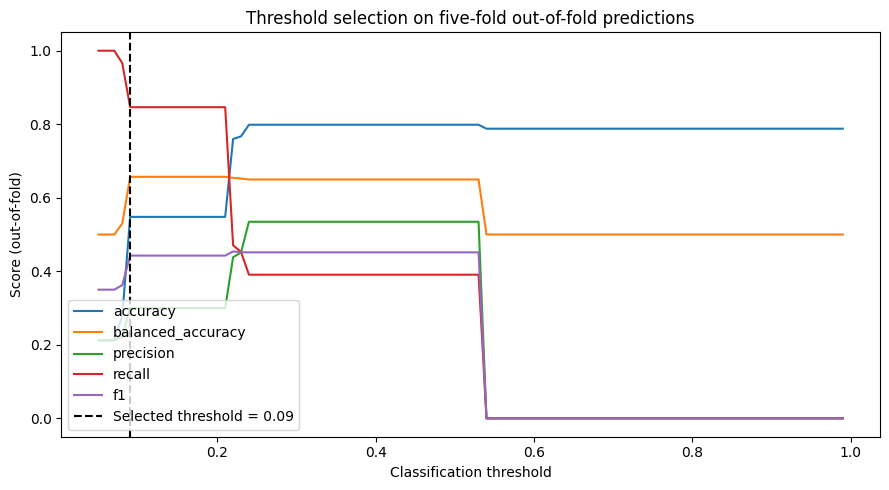

In [76]:
fig, ax = plt.subplots(figsize=(9, 5))

for metric in [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1"
]:
    ax.plot(
        threshold_results["threshold"],
        threshold_results[metric],
        label=metric
    )

ax.axvline(
    CHOSEN_THRESHOLD,
    linestyle="--",
    color="black",
    label=f"Selected threshold = {CHOSEN_THRESHOLD:.2f}"
)

ax.set_xlabel("Classification threshold")
ax.set_ylabel("Score (out-of-fold)")
ax.set_title(
    "Threshold selection on five-fold out-of-fold predictions"
)
ax.legend()

plt.tight_layout()
plt.show()


In [77]:
oof_predictions = (
    oof_probabilities >= CHOSEN_THRESHOLD
).astype(int)

oof_results["predicted_class"] = oof_predictions

oof_results.head()


,row_id,true_class,probability_class_1,predicted_class
0,CR26-120473,0,0.213592,1
1,CR26-127004,0,0.216340,1
2,CR26-116408,0,0.081406,0
3,CR26-125768,0,0.214603,1
4,CR26-118040,0,0.216004,1


## 8. Local Explanations

In addition to the global interpretation of the CART model, we analyze
individual predictions.

To avoid selecting examples based only on predictions made on the same data
used to train the model, we use the out-of-fold predictions obtained above.

Two representative observations are selected:

- one observation whose true class is 0;
- one observation whose true class is 1.

The local explanations in this section refer to the final CART model. These
same cases will be retained for the subsequent comparison of explanations
provided by different models.

In [78]:
print(
    f"Accuracy:          "
    f"{accuracy_score(y, oof_predictions):.4f}"
)

print(
    f"Balanced accuracy: "
    f"{balanced_accuracy_score(y, oof_predictions):.4f}"
)

print(
    f"F1:                "
    f"{f1_score(y, oof_predictions):.4f}"
)

print(
    f"ROC-AUC:           "
    f"{roc_auc_score(y, oof_probabilities):.4f}"
)

print("\nMatriz de confusión:")
print(confusion_matrix(y, oof_predictions))

Accuracy:          0.5480
Balanced accuracy: 0.6570
F1:                0.4427
ROC-AUC:           0.7209

Matriz de confusión:
[[ 9212 10485]
 [  815  4488]]


Saved: ../report/images/figure_12.png


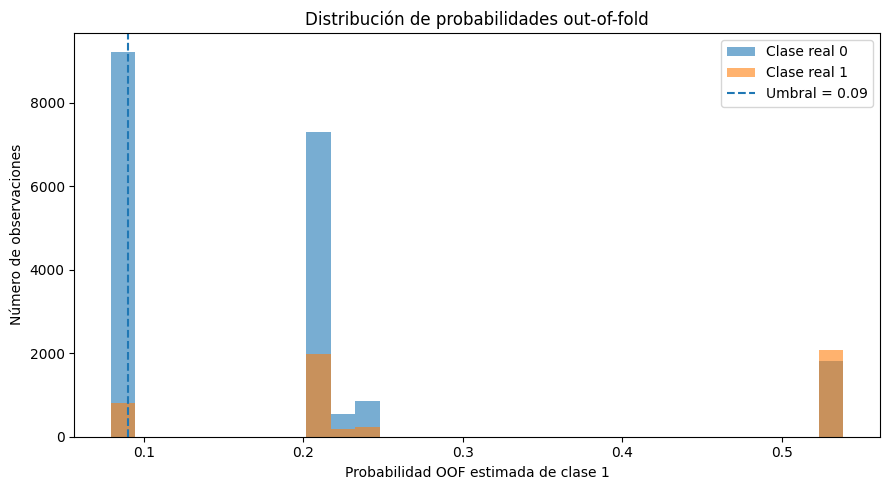

In [79]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    oof_results.loc[
        oof_results["true_class"] == 0,
        "probability_class_1"
    ],
    bins=30,
    alpha=0.6,
    label="Clase real 0"
)

ax.hist(
    oof_results.loc[
        oof_results["true_class"] == 1,
        "probability_class_1"
    ],
    bins=30,
    alpha=0.6,
    label="Clase real 1"
)

ax.axvline(
    CHOSEN_THRESHOLD,
    linestyle="--",
    label=f"Umbral = {CHOSEN_THRESHOLD:.2f}"
)

ax.set_xlabel("Probabilidad OOF estimada de clase 1")
ax.set_ylabel("Número de observaciones")
ax.set_title("Distribución de probabilidades out-of-fold")

ax.legend()

plt.tight_layout()
plt.show()

In [80]:
correct_oof = oof_results[
    oof_results["true_class"]
    == oof_results["predicted_class"]
].copy()

selected_cases = []

for target_class in [0, 1]:

    candidates = correct_oof[
        correct_oof["true_class"] == target_class
    ].copy()

    median_probability = candidates[
        "probability_class_1"
    ].median()

    candidates["distance_to_median"] = (
        candidates["probability_class_1"]
        - median_probability
    ).abs()

    selected_case = candidates.sort_values(
        "distance_to_median"
    ).iloc[0]

    selected_cases.append(selected_case)

selected_cases = pd.DataFrame(
    selected_cases
).reset_index(drop=True)

selected_cases

,row_id,true_class,probability_class_1,predicted_class,distance_to_median
0,CR26-103063,0,0.081406,0,0.0
1,CR26-125466,1,0.233425,1,0.0


In [81]:
selected_row_ids = selected_cases["row_id"].tolist()

selected_instances = train[
    train[ID_COLUMN].isin(selected_row_ids)
].copy()

selected_instances

,row_id,credit_limit,sex,education,marital_status,age,latest_repayment_status,maximum_repayment_delay_6m,delayed_months_6m,average_bill_6m,bill_change_sep_to_apr,total_payment_6m,payment_to_bill_ratio_6m,zero_payment_months_6m,utilization_sep,repayment_assistance_plan,payment_difficulty_next_month
114,CR26-125466,350000,female,university,other_or_unknown,44,2,2,2,55900,-244400,305600,0.87,3,0.15,no,1
5151,CR26-103063,210000,female,graduate_school,single,31,-1,0,0,600,1500,3200,0.82,1,0.01,no,0


In [82]:
X_selected = selected_instances[SELECTED_FEATURES]

final_probabilities = final_model.predict_proba(
    X_selected
)[:, 1]

final_predictions = final_model.predict(
    X_selected
)

local_predictions = selected_instances[
    [ID_COLUMN, TARGET]
].copy()

local_predictions[
    "predicted_class"
] = final_predictions

local_predictions[
    "probability_class_1"
] = final_probabilities

local_predictions

,row_id,payment_difficulty_next_month,predicted_class,probability_class_1
114,CR26-125466,1,0,0.232967
5151,CR26-103063,0,0,0.081281


In [83]:
X_selected_transformed = (
    final_model
    .named_steps["preprocessor"]
    .transform(X_selected)
)

assigned_leaves = final_tree.apply(
    X_selected_transformed
)

local_predictions[
    "leaf_node"
] = assigned_leaves

local_predictions

,row_id,payment_difficulty_next_month,predicted_class,probability_class_1,leaf_node
114,CR26-125466,1,0,0.232967,6
5151,CR26-103063,0,0,0.081281,3


In [84]:
for _, row in local_predictions.iterrows():

    row_id = row[ID_COLUMN]
    leaf_node = int(row["leaf_node"])
    probability_class_1 = row["probability_class_1"]

    # Prediction using the standard threshold (0.5)
    prediction_default = int(
        probability_class_1 >= 0.5
    )

    # Prediction using the threshold selected by cross-validation
    prediction_selected = int(
        probability_class_1 >= CHOSEN_THRESHOLD
    )

    rule = get_leaf_rule(
        final_tree,
        feature_names,
        leaf_node
    )

    print("=" * 70)
    print(f"Observation: {row_id}")
    print(f"True class: {int(row[TARGET])}")
    print(
        f"P(class 1): "
        f"{probability_class_1:.3f}"
    )
    print(
        f"Prediction (threshold = 0.50): "
        f"{prediction_default}"
    )
    print(
        f"Prediction (threshold = {CHOSEN_THRESHOLD:.2f}): "
        f"{prediction_selected}"
    )
    print(f"Leaf: {leaf_node}")

    print("\nDecision path:")

    for condition in rule:
        print(f"  {condition}")

    print()

Observation: CR26-125466
True class: 1
P(class 1): 0.233
Prediction (threshold = 0.50): 0
Prediction (threshold = 0.09): 1
Leaf: 6

Decision path:
  latest_repayment_status > 0.500
  payment_to_bill_ratio_6m > 0.105

Observation: CR26-103063
True class: 0
P(class 1): 0.081
Prediction (threshold = 0.50): 0
Prediction (threshold = 0.09): 0
Leaf: 3

Decision path:
  latest_repayment_status <= 0.500
  payment_to_bill_ratio_6m > 0.105



Saved: ../report/images/figure_13.png


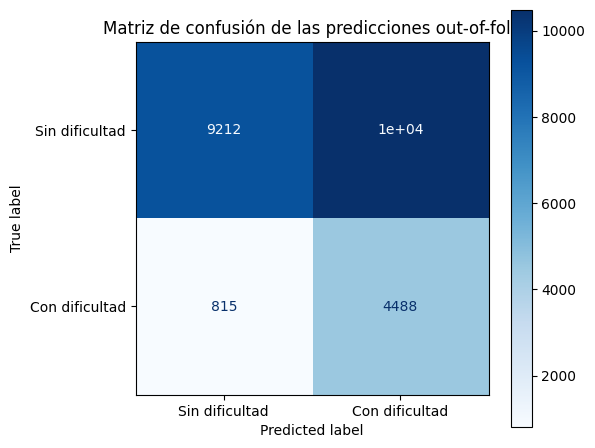

In [85]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y,
    oof_predictions,
    display_labels=[
        "Sin dificultad",
        "Con dificultad"
    ],
    cmap="Blues",
    ax=ax
)

ax.set_title(
    "Matriz de confusión de las predicciones out-of-fold"
)

plt.tight_layout()
plt.show()

In [86]:
print(
    classification_report(
        y,
        oof_predictions,
        target_names=[
            "Sin dificultad",
            "Con dificultad"
        ],
        digits=4
    )
)

                precision    recall  f1-score   support

Sin dificultad     0.9187    0.4677    0.6198     19697
Con dificultad     0.2997    0.8463    0.4427      5303

      accuracy                         0.5480     25000
     macro avg     0.6092    0.6570    0.5313     25000
  weighted avg     0.7874    0.5480    0.5823     25000



In [87]:
results_table = pd.DataFrame({
    "Clasificador": [
        "DecisionTreeClassifier"
    ],
    "Configuración principal": [
        (
            f"max_depth={FINAL_MAX_DEPTH}, "
            f"min_samples_leaf={FINAL_MIN_SAMPLES_LEAF}, "
            f"{len(SELECTED_FEATURES)} predictors (forward selection)"
        )
    ],
    "Umbral": [
        CHOSEN_THRESHOLD
    ],
    "Accuracy CV": [
        accuracy_score(y, oof_predictions)
    ],
    "Balanced accuracy CV": [
        balanced_accuracy_score(y, oof_predictions)
    ],
    "F1 CV": [
        f1_score(y, oof_predictions)
    ],
    "ROC-AUC CV": [
        final_cv_results["test_roc_auc"].mean()
    ],
    "ROC-AUC std": [
        final_cv_results["test_roc_auc"].std()
    ]
})

results_table.round(4)


,Clasificador,Configuración principal,Umbral,Accuracy CV,Balanced accuracy CV,F1 CV,ROC-AUC CV,ROC-AUC std
0,DecisionTreeClassifier,"max_depth=2, min_samples_leaf=200, 2 predictor...",0.09,0.548,0.657,0.4427,0.7237,0.0069


## 9. Preliminary Discussion

The unrestricted CART model showed substantial overfitting, achieving almost
perfect performance on the training data but a mean ROC-AUC of approximately
0.595 under five-fold cross-validation. In addition, the resulting tree
contained 8,911 nodes and 4,456 leaves, making direct global interpretation
impractical.

Restricting tree complexity substantially improved both generalization and
interpretability. Although deeper trees achieved higher ROC-AUC values, a
maximum depth of 2 was selected because it provides a particularly compact
structure while achieving higher balanced accuracy and F1 score than the deeper
alternatives considered. For this depth, varying `min_samples_leaf` between 1
and 500 did not change the resulting cross-validation performance, and a value
of 200 was retained as a conservative constraint.

Forward feature selection further reduced the CART model to two predictors:
`latest_repayment_status` and `payment_to_bill_ratio_6m`. The resulting tree has
an effective depth of 2, with 3 decision nodes, 4 terminal leaves and 7 total
nodes. Under five-fold cross-validation, it achieves a mean accuracy of
approximately 0.799, balanced accuracy of 0.650, F1 score of 0.452 and ROC-AUC
of 0.724.

As an alternative logical model, we also evaluated GOSDT. Its regularization
parameter was selected using five-fold cross-validation, resulting in a value
of 0.0005. Although the optimization allowed a maximum depth of 6, the learned
tree reached an effective depth of only 3, with 4 decision nodes, 5 leaves and
9 total nodes. GOSDT also relied on the same two original predictors used by
CART.

GOSDT achieved a slightly higher mean cross-validated accuracy than CART
(0.807 versus 0.799), whereas CART achieved higher balanced accuracy
(0.650 versus 0.621) and F1 score (0.452 versus 0.396). Structurally, both
models remain small enough for direct inspection, although CART produces the
more compact tree. These results illustrate the trade-off between predictive
performance and structural simplicity rather than establishing a universally
superior logical model.

The final CART model relies entirely on variables describing recent payment
behavior. Both CART and GOSDT independently use
`latest_repayment_status` and `payment_to_bill_ratio_6m`, although the models
construct different decision structures from them. These associations describe
the predictive behavior learned from the data and should not be interpreted as
causal relationships.

Finally, the classification threshold of the CART model was selected using
out-of-fold predictions. Maximizing balanced accuracy resulted in a threshold
of 0.09. At this threshold, the model achieves an out-of-fold balanced accuracy
of approximately 0.657, recall of 0.846 for the positive class and an overall
accuracy of 0.548. This represents a substantially more sensitive classifier
for payment difficulty, at the cost of a larger number of false positives.
The threshold was selected exclusively from the training data without using
the test set.

##### Selected Cases for Local Explanations

To facilitate the subsequent comparison of local explanations, the following
observations are retained:

- **CR26-125466**: true class 1. The final CART model assigns an estimated
  probability of payment difficulty of approximately 0.233. With the default
  threshold of 0.50, the observation would be classified as class 0. However,
  using the threshold of 0.09 selected by cross-validation, it is classified
  as class 1.

- **CR26-103063**: true class 0. The final CART model assigns an estimated
  probability of payment difficulty of approximately 0.081. The observation is
  classified as class 0 using both the default threshold of 0.50 and the
  selected threshold of 0.09.

The decision paths remain unchanged when the classification threshold is
modified, since the threshold only determines how the probability estimated
at the terminal leaf is converted into a class prediction.

These same observations can subsequently be used to analyze and compare local
explanations produced by different models.